# Experiments 7-9

### Dataset:
- **Dataset:** 5m | 90º
- **Sizes:** small & mid
- **Split:** 240 px
- **Tags:**  `plant-weed`
- **Train/Valid dist:** 66,6% / 33,3%

### Model:
- **Model:** `yolov8n` *(Nano)*
- **Epochs:** 100
- **Batch:** 64
- **Freeze:** 10

### Experiments:
1. small + mid
2. small
3. mid

In [256]:
# CONFIG FOLDER PATH

# Get the project root directory (replace with your actual path)
project_root = "../../"
experiment_number = 3

# The folder you want to navigate to (relative to the root)
target_folder = f"docs/Experimentos/2 Finetuning/{experiment_number} set/runs/detect/"

### Init

In [257]:
scale: int = 500 # size for graphs (in pixels)

In [258]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D

In [259]:
# Construct the full path
target_path = os.path.join(project_root, target_folder)

# Change the current working directory
try:
    os.chdir(target_path)
    print(f"Current working directory: {os.getcwd()}")  # Verify
except FileNotFoundError:
    print(f"Error: Folder '{target_path}' not found. Check the path.")
except NotADirectoryError:
    print(f"Error: '{target_path}' is not a directory.")
except Exception as e:
    print(f"An error occurred: {e}")

Error: Folder '../../docs/Experimentos/2 Finetuning/3 set/runs/detect/' not found. Check the path.


In [260]:
# Reset to the root path
# os.chdir(project_root)
# print(f"Current working directory: {os.getcwd()}") #Verify

In [261]:
best_models = pd.DataFrame(
    columns=['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
       'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
       'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2', 'train_time'],
       data = None
       )

#### Functions

In [262]:
def graph_training_metrics(df: pd.DataFrame, epoch: np.int64, graph: str="tight"):
    """
    Plots training and validation metrics from a training log DataFrame.

    Args:
        df (pd.DataFrame): DataFrame containing training metrics, including columns
                           'epoch', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss',
                           'val/box_loss', 'val/cls_loss', 'val/dfl_loss',
                           'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)',
                           'metrics/mAP50-95(B)', and optionally 'lr/pg0' for the 'lr' graph.
        graph (str, optional): Type of graph to display. Options are:
            - "tight": Displays loss and metrics in a single row.
            - "full": Displays loss and metrics in two rows.
            - "lr": Displays loss, metrics, and learning rate in three rows.
            Defaults to "tight".

    Raises:
        ValueError: If the 'graph' parameter is not one of "tight", "full", or "lr".
    """
    graph = graph.lower()

    # Tight view (one row)
    if graph == "tight":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 6))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(1, 2, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

        # Graficar métricas de validación
        plt.subplot(1, 2, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X
        plt.legend()


    # Full view (two rows)
    elif graph == "full":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 12))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(2, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

        # Graficar métricas de validación
        plt.subplot(2, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--')
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X

    # Shows also Lr graph (three rows)
    elif graph == "lr":
        # Configurar el tamaño de las figuras
        plt.figure(figsize=(15, 15))

        # Graficar pérdidas de entrenamiento y validación
        plt.subplot(3, 1, 1)
        plt.plot(df["epoch"], df["train/box_loss"], label="Train Box Loss")
        plt.plot(df["epoch"], df["train/cls_loss"], label="Train Cls Loss")
        plt.plot(df["epoch"], df["train/dfl_loss"], label="Train DFL Loss")
        plt.plot(df["epoch"], df["val/box_loss"], label="Val Box Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/cls_loss"], label="Val Cls Loss", linestyle="dashed")
        plt.plot(df["epoch"], df["val/dfl_loss"], label="Val DFL Loss", linestyle="dashed")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

        # Graficar métricas de validación
        plt.subplot(3, 1, 2)
        plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
        plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
        plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
        plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
        plt.xlabel("Epoch")
        plt.ylabel("Metric Score")
        plt.title("Validation Metrics")
        plt.grid(True)
        plt.legend()

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.plot(epoch, df.loc[df["epoch"] == epoch, "metrics/mAP50(B)"].values[0], 'rx', markersize=10) # add red X
        plt.legend()

        # Gráfico de evolución del learning rate
        plt.subplot(3, 1, 3)
        plt.plot(df["epoch"], df["lr/pg0"], label="Learning Rate (pg0)", color="cadetblue", marker='.', linestyle='-')
        plt.xlabel("Epoch")
        plt.ylabel("Learning Rate")
        plt.title("Learning Rate Evolution")
        plt.grid(True)

        # Best epoch
        plt.axvline(x=epoch, color='gray', linestyle='--', label=f"Best Epoch: {epoch}")
        plt.legend()

    else:
        raise ValueError(f"Invalid graph parameter: '{graph}'. Must be one of 'tight', 'full', or 'lr'.")

    plt.tight_layout()
    plt.show()

In [263]:
def graph_LrLoss(df):
    """Generates a 3D plot of Learning Rate vs. Loss vs. Epoch."""

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Data
    epochs = df['epoch']
    losses = df['val/cls_loss']  # or df['train/cls_loss'], or combined as needed.
    lrs = df['lr/pg0']

    # Scatter plot
    ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis', marker='o')

    # Labels
    ax.set_xlabel('Learning Rate (lr/pg0)')
    ax.set_ylabel('Classification Loss (val/cls_loss)')
    ax.set_zlabel('Epoch')
    ax.set_title('3D Plot: Learning Rate vs. Loss vs. Epoch')

    # Color bar
    fig.colorbar(ax.scatter(lrs, losses, epochs, c=losses, cmap='viridis'), label='Loss Value')

    plt.show()

In [264]:
def graph_LrLoss_3D(df, set: str='val'):
    """Generates an interactive 3D plot of Learning Rate vs. Loss vs. Epoch."""

    if set.lower() == 'val':
        print("Validation set")
        loss_set = 'val/cls_loss'
        title_set = 'Validation'
    elif set.lower() == 'train':
        print("Training set")
        loss_set = 'train/cls_loss'
        title_set = 'Train'
    else:
        print("Debe indicarse el set de entrenamiento: set debe ser igual 'val' o 'train'")
        return  

    fig = go.Figure(data=[go.Scatter3d(
        x=df['lr/pg0'],
        y=df[loss_set],
        z=df['epoch'],
        mode='markers',
        marker=dict(
            size=5,
            color=df[loss_set], # color based on loss value
            colorscale='Viridis',
            opacity=0.8,
            colorbar=dict(title='Loss Value')  # Add colorbar
        )
    )])

    fig.update_layout(
        margin=dict(l=0, r=0, b=0, t=0),
        scene=dict(
            xaxis=dict(title='Learning Rate (lr/pg0)'),
            yaxis=dict(title=f'Classification Loss ({loss_set})'),
            zaxis=dict(title='Epoch'),
        ),
        title=f'Learning Rate vs. {title_set} Loss vs. Epoch'
    )

    fig.show()

----

# Experimentos

## Experiment 7 *(full dataset)*
### *5m | 90º | small + mid*

In [265]:
folder = "train/"

In [266]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df1 = pd.read_csv(file_path)
df = df1.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
95,96,944.626,2.91637,2.16601,1.59333,0.08605,0.09650,0.02617,0.00673,2.74057,19.6130,1.41317,0.000085,0.000085,0.000085
96,97,954.049,2.89595,2.16323,1.59392,0.08649,0.08965,0.02607,0.00665,2.75189,20.8133,1.42065,0.000071,0.000071,0.000071
97,98,962.448,2.91057,2.15160,1.59667,0.08002,0.10282,0.02705,0.00667,2.75068,22.4896,1.42090,0.000057,0.000057,0.000057
98,99,972.253,2.89710,2.16439,1.59487,0.08186,0.10227,0.02801,0.00702,2.75051,21.4776,1.42032,0.000043,0.000043,0.000043
99,100,981.760,2.92121,2.15570,1.58581,0.07755,0.10133,0.02785,0.00694,2.75009,20.7087,1.42120,0.000028,0.000028,0.000028


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [267]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 16.363 min


#### Best epoch

In [268]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
89,90,887.53,2.96676,2.12934,1.54329,0.0691,0.11065,0.02936,0.00731,2.767,20.9898,1.41812,0.00017,0.00017,0.00017,16.362667


In [269]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 90 con mAP50 de 0.029


In [270]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [271]:
TP = 36+4
FP = 124+1
FN = 1921+521
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 2607


In [272]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.01534330648254699, 0.04794783275795934, 0.9367088607594937)

### Graphs

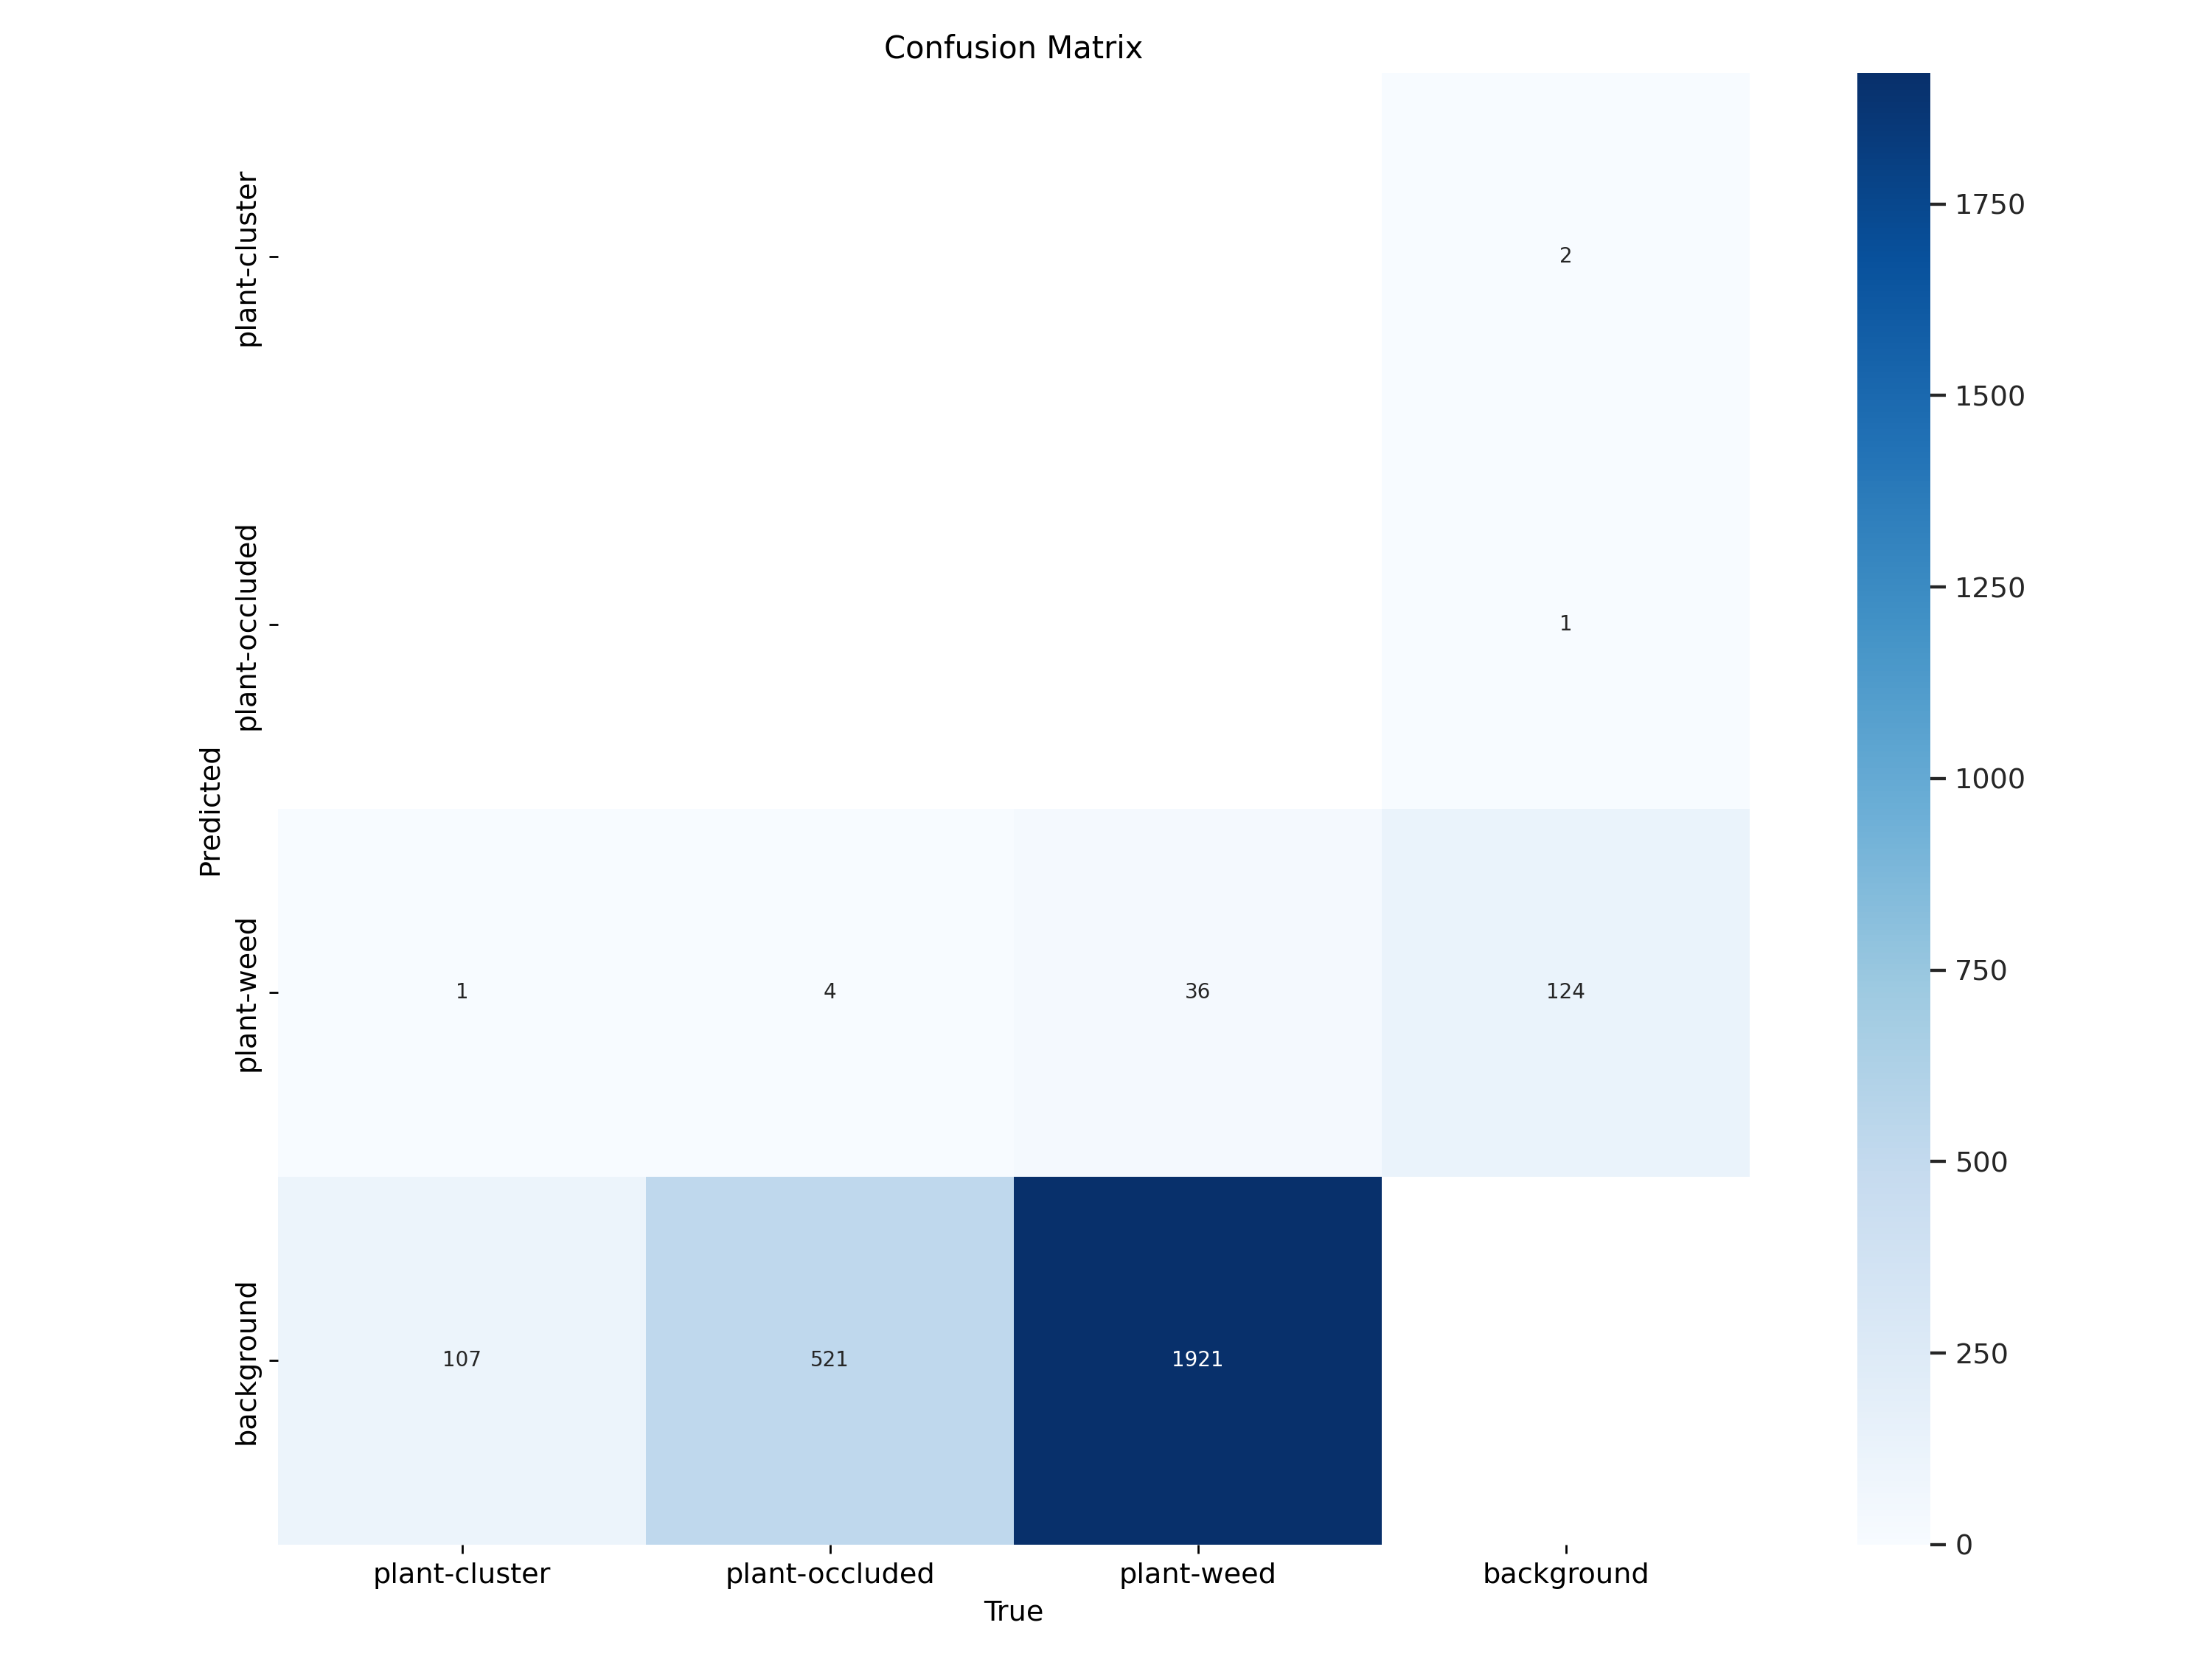

In [273]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

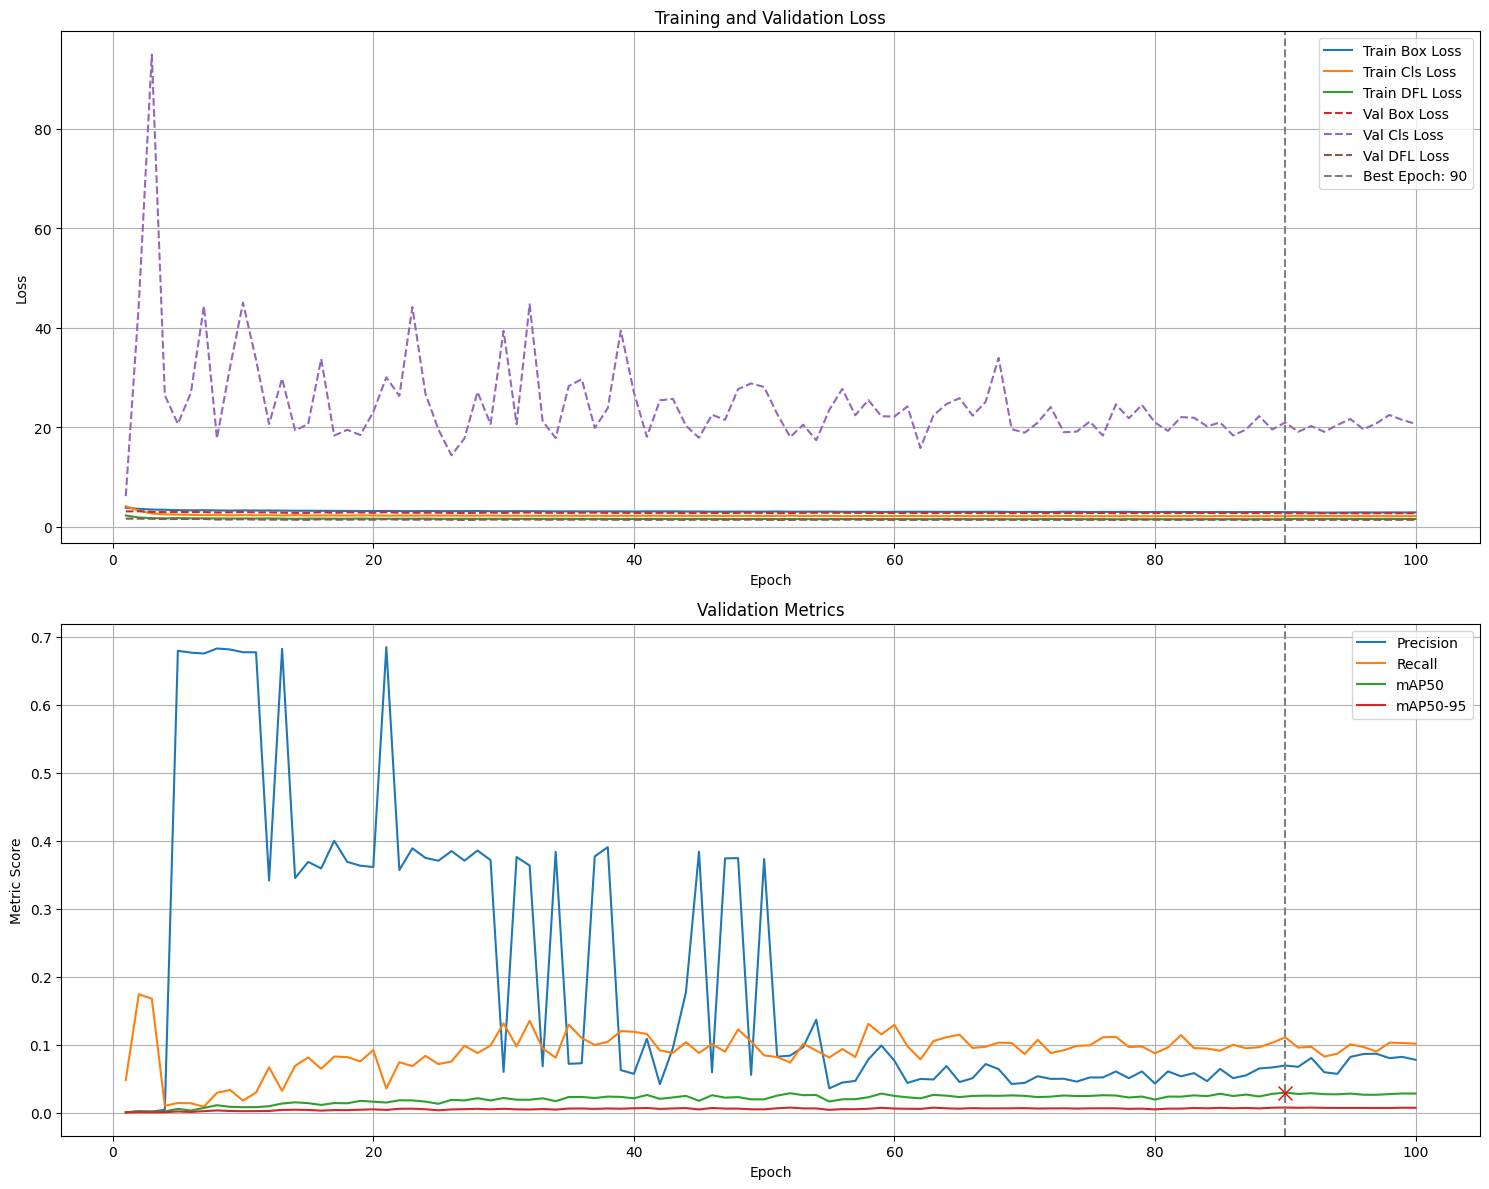

In [274]:
graph_training_metrics(df1, epoch, graph="full")

In [275]:
graph_LrLoss_3D(df1)

Validation set


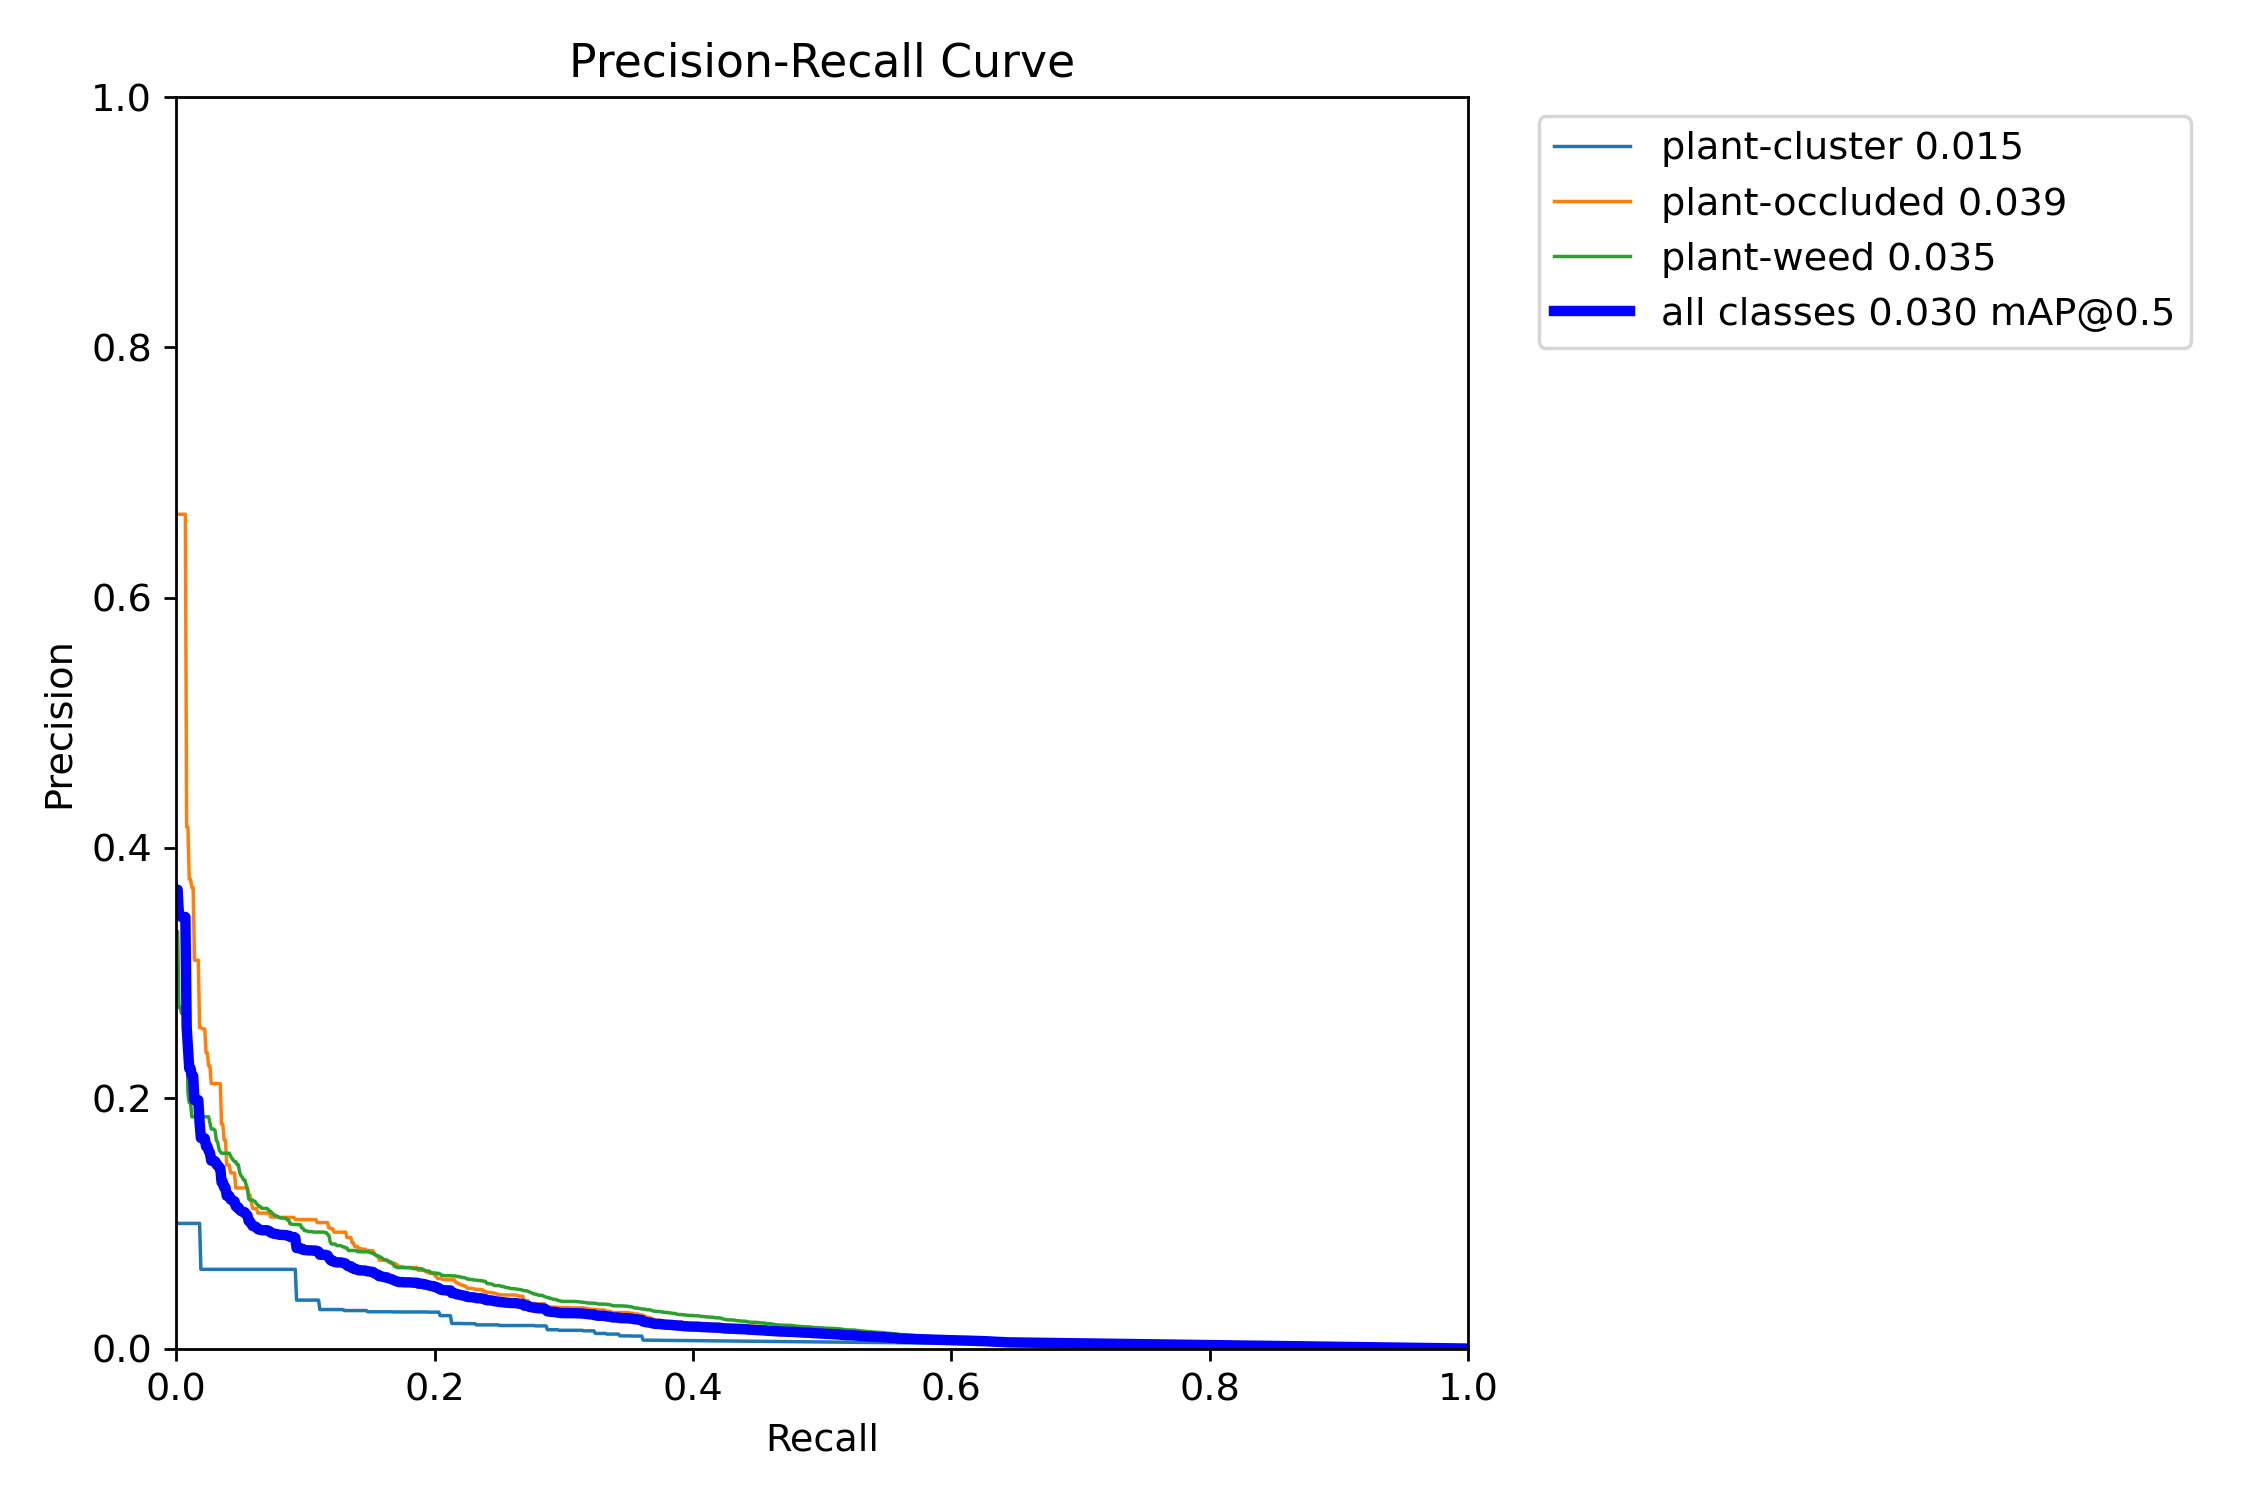

In [276]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

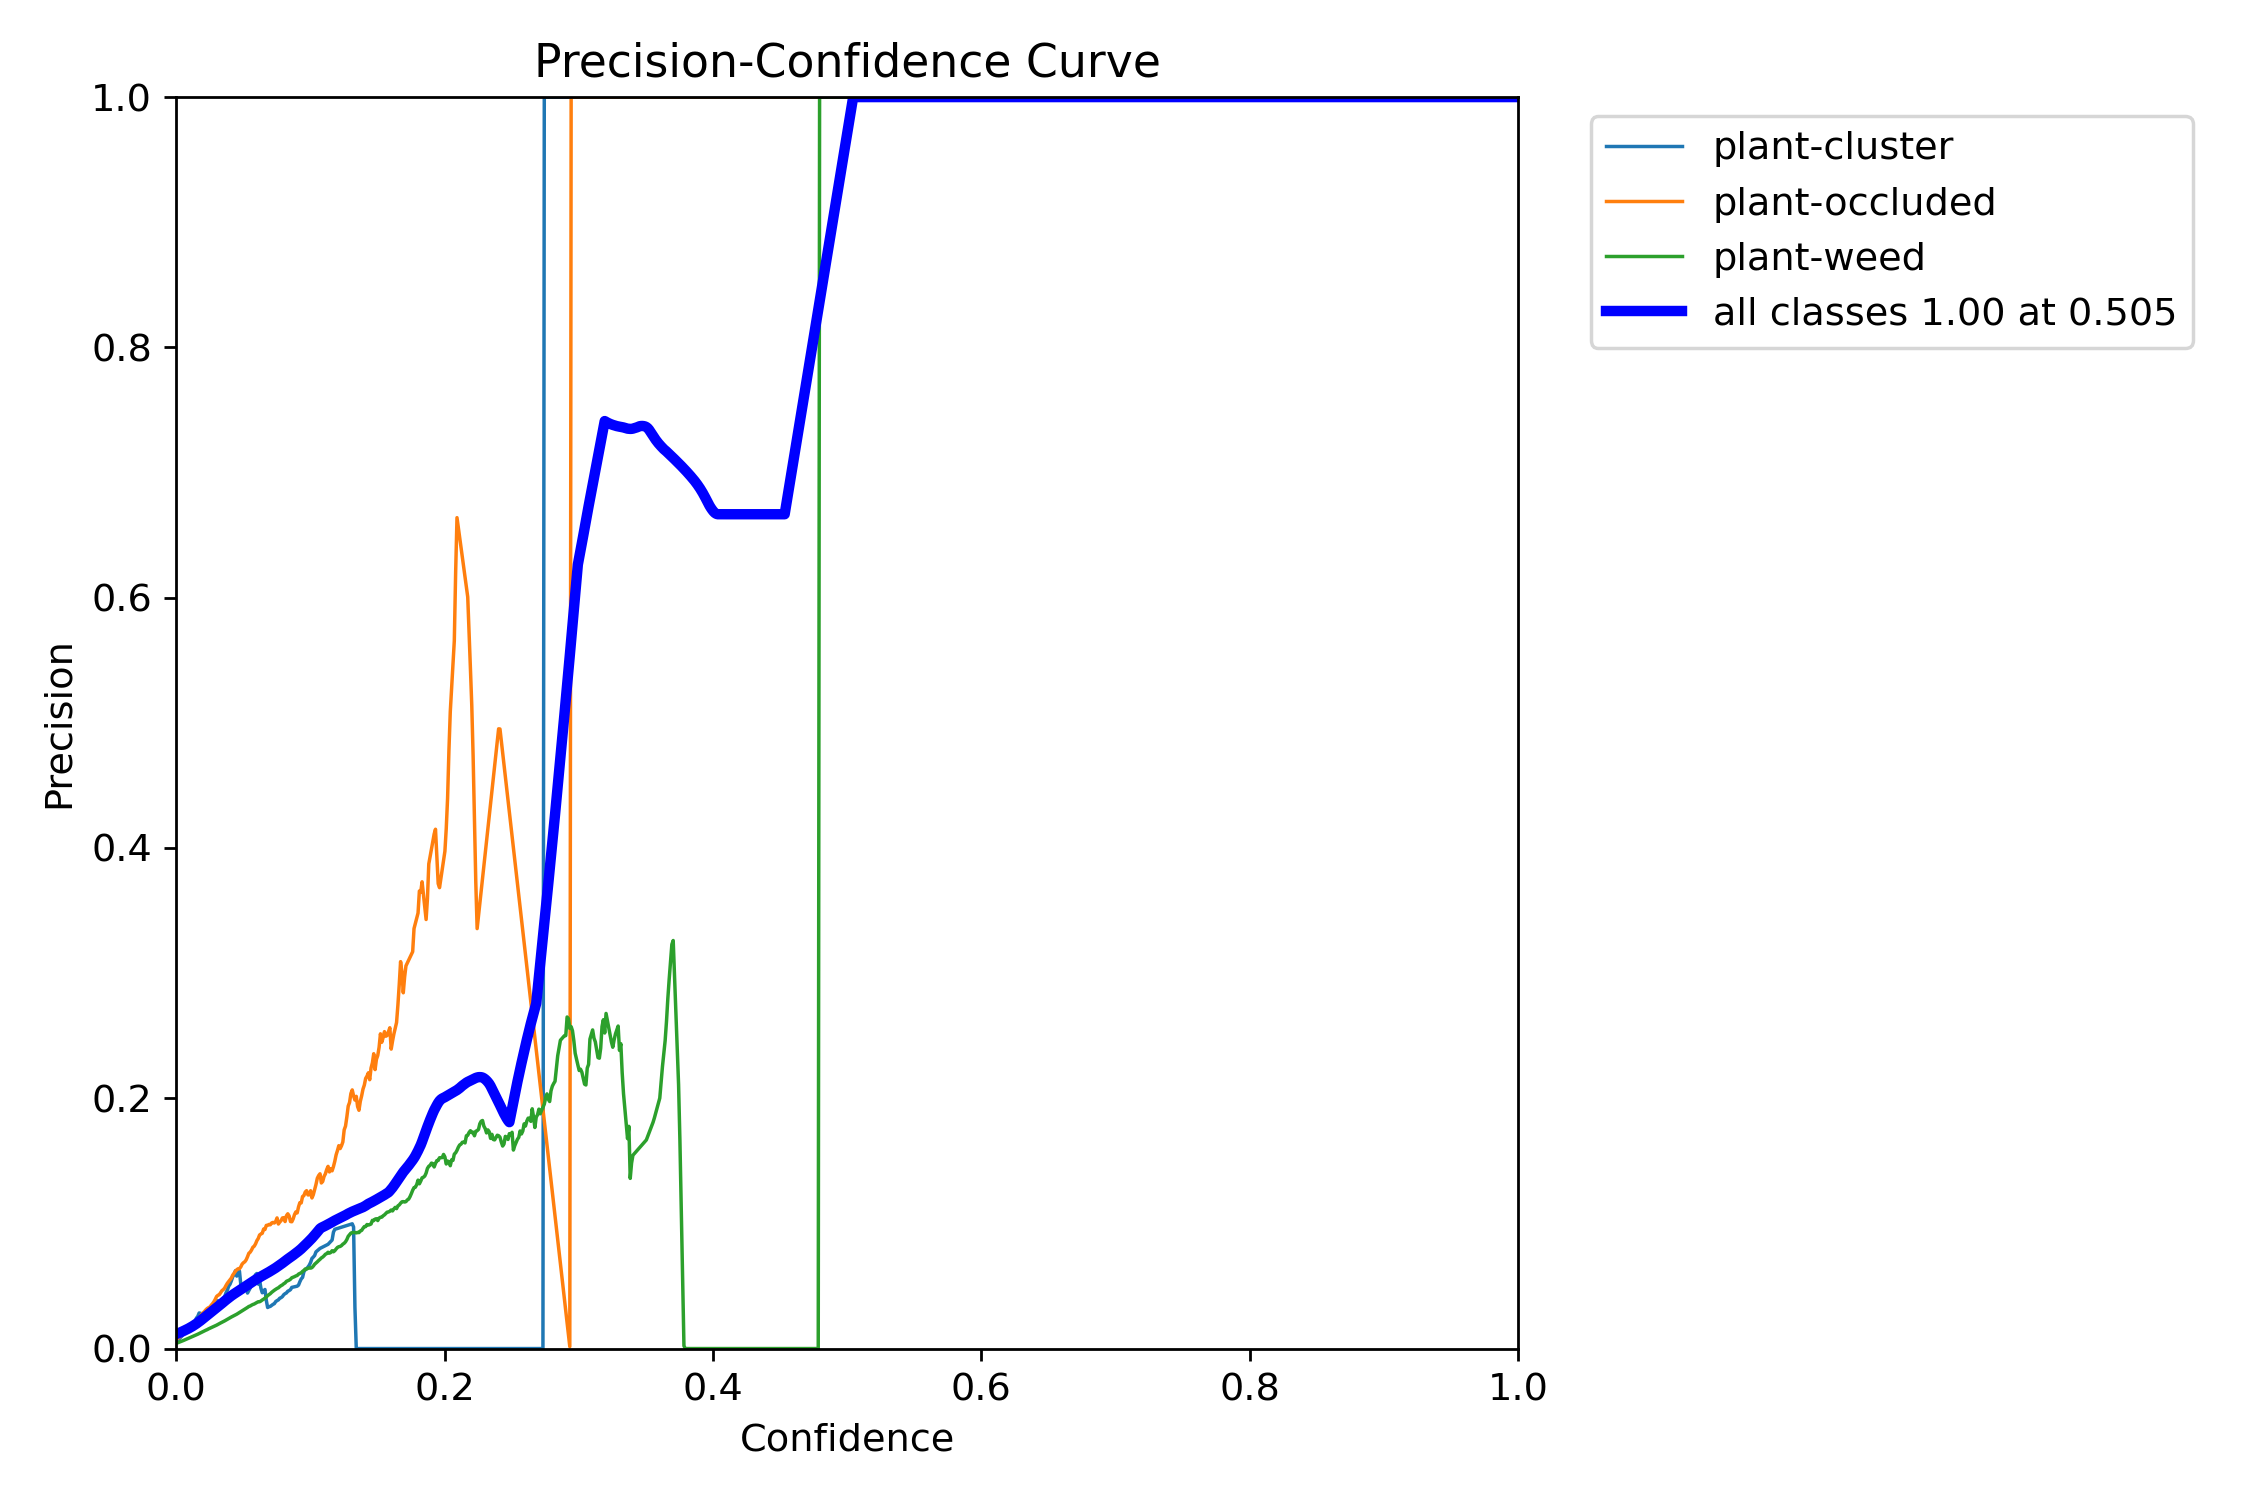

In [277]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

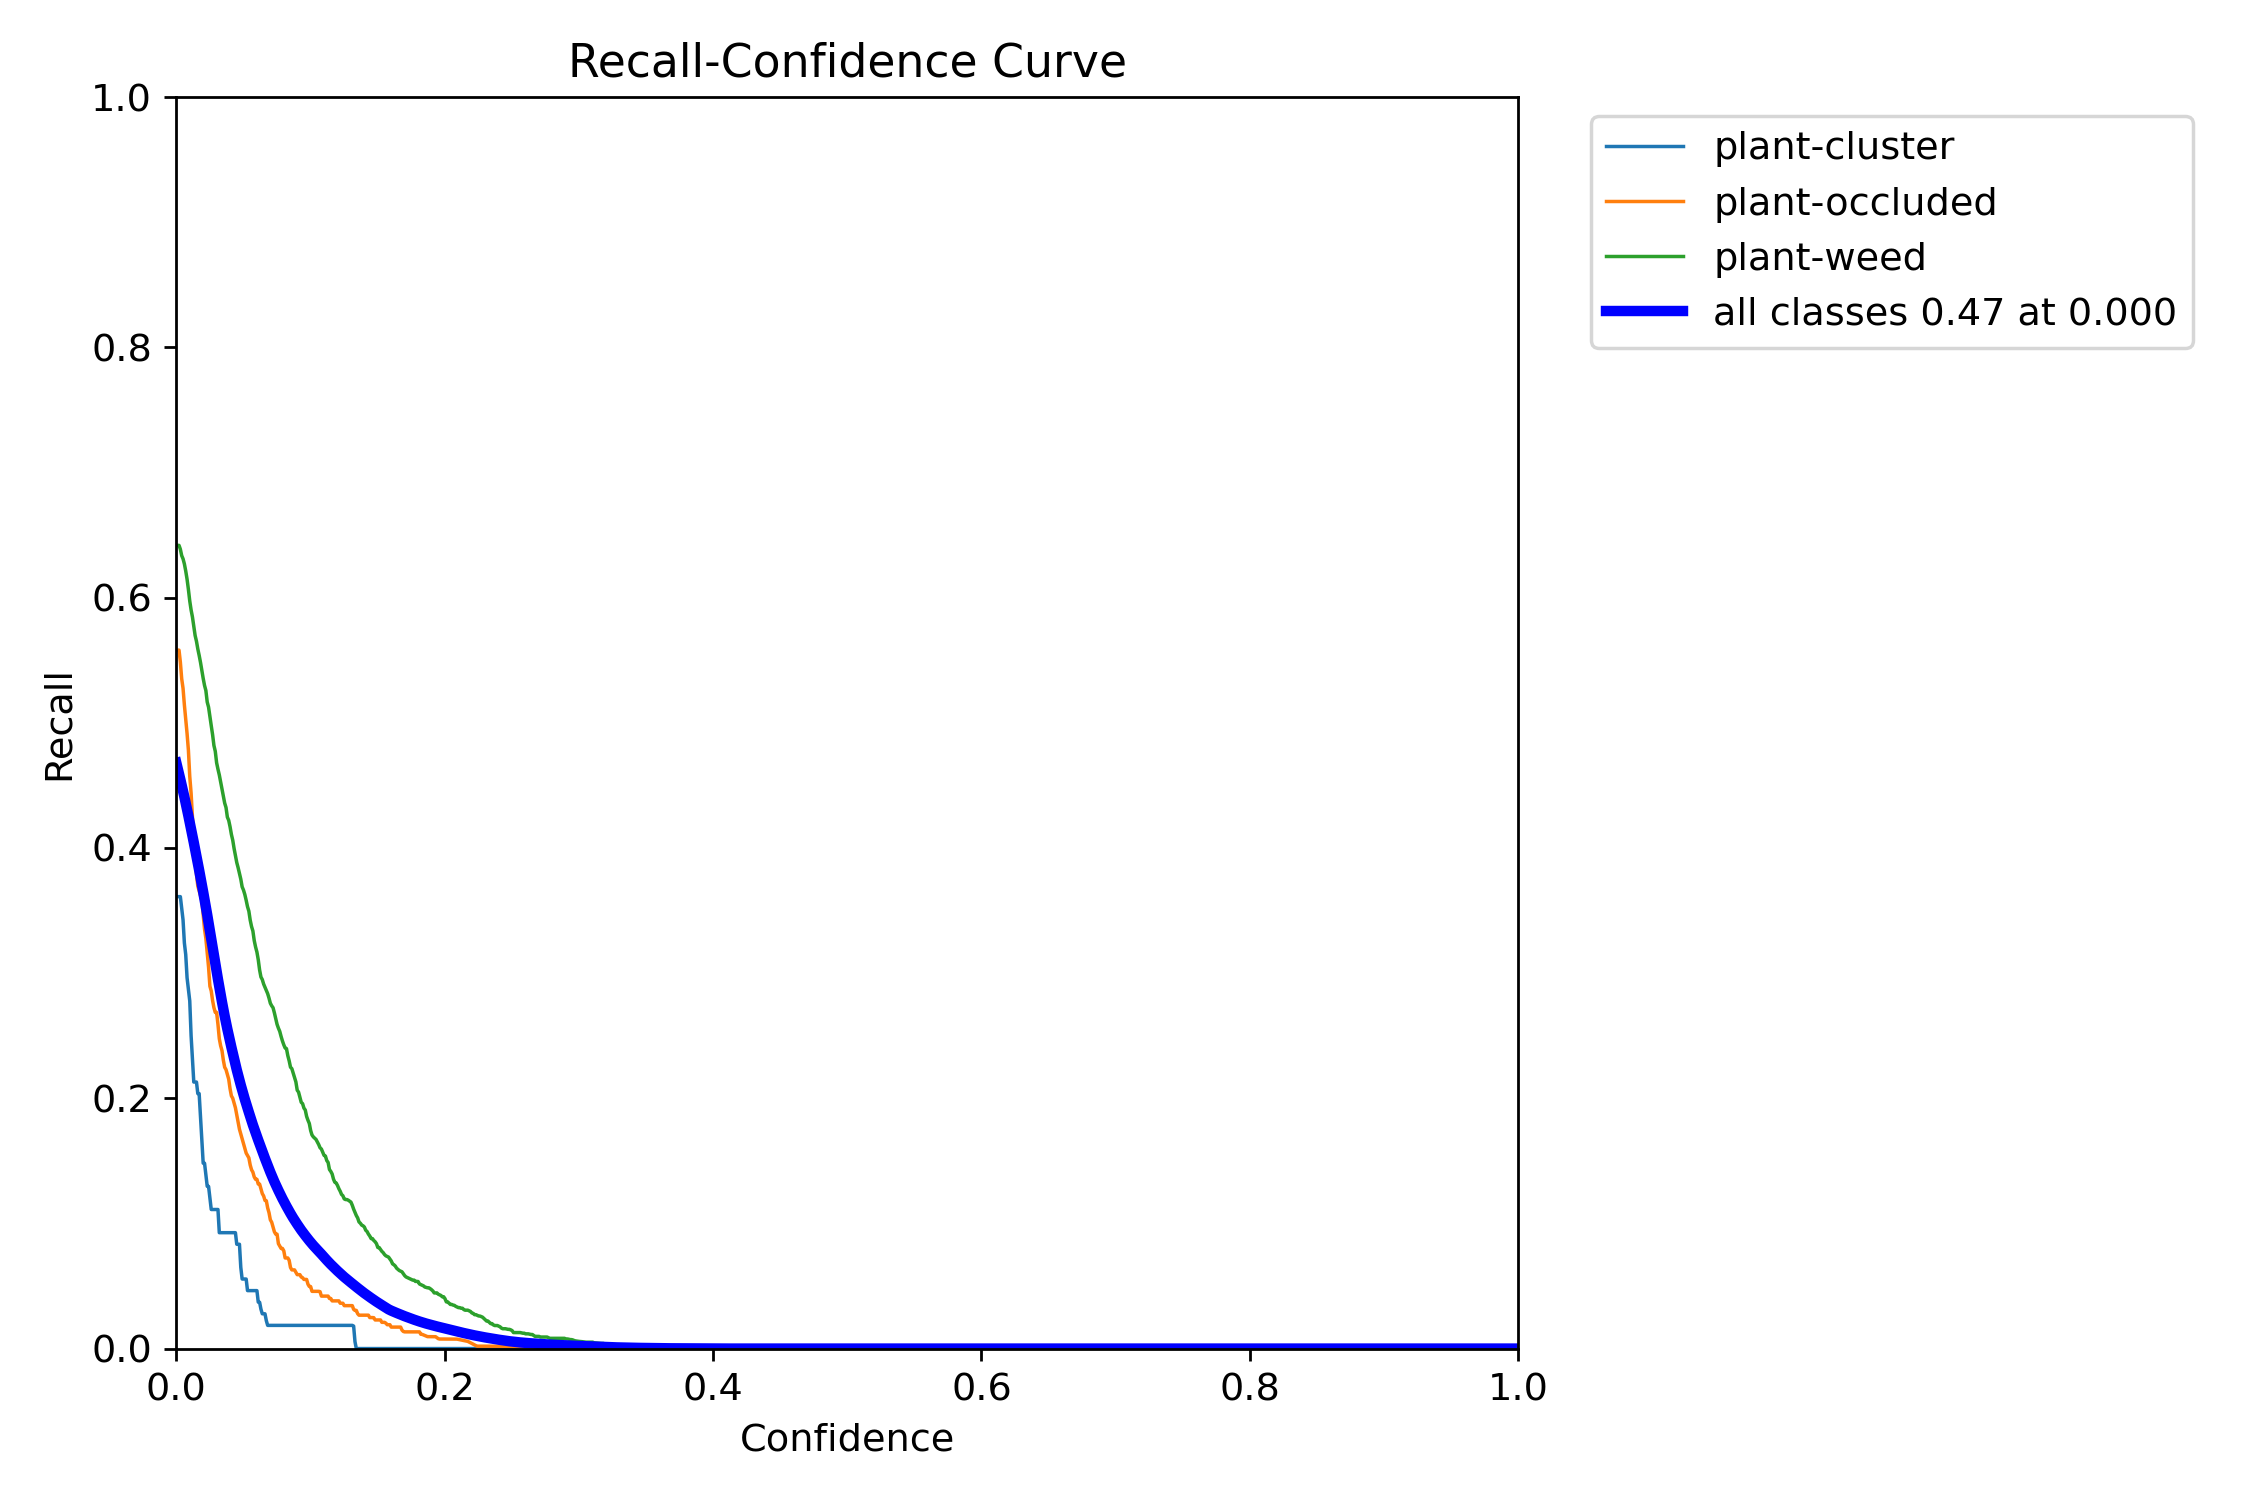

In [278]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

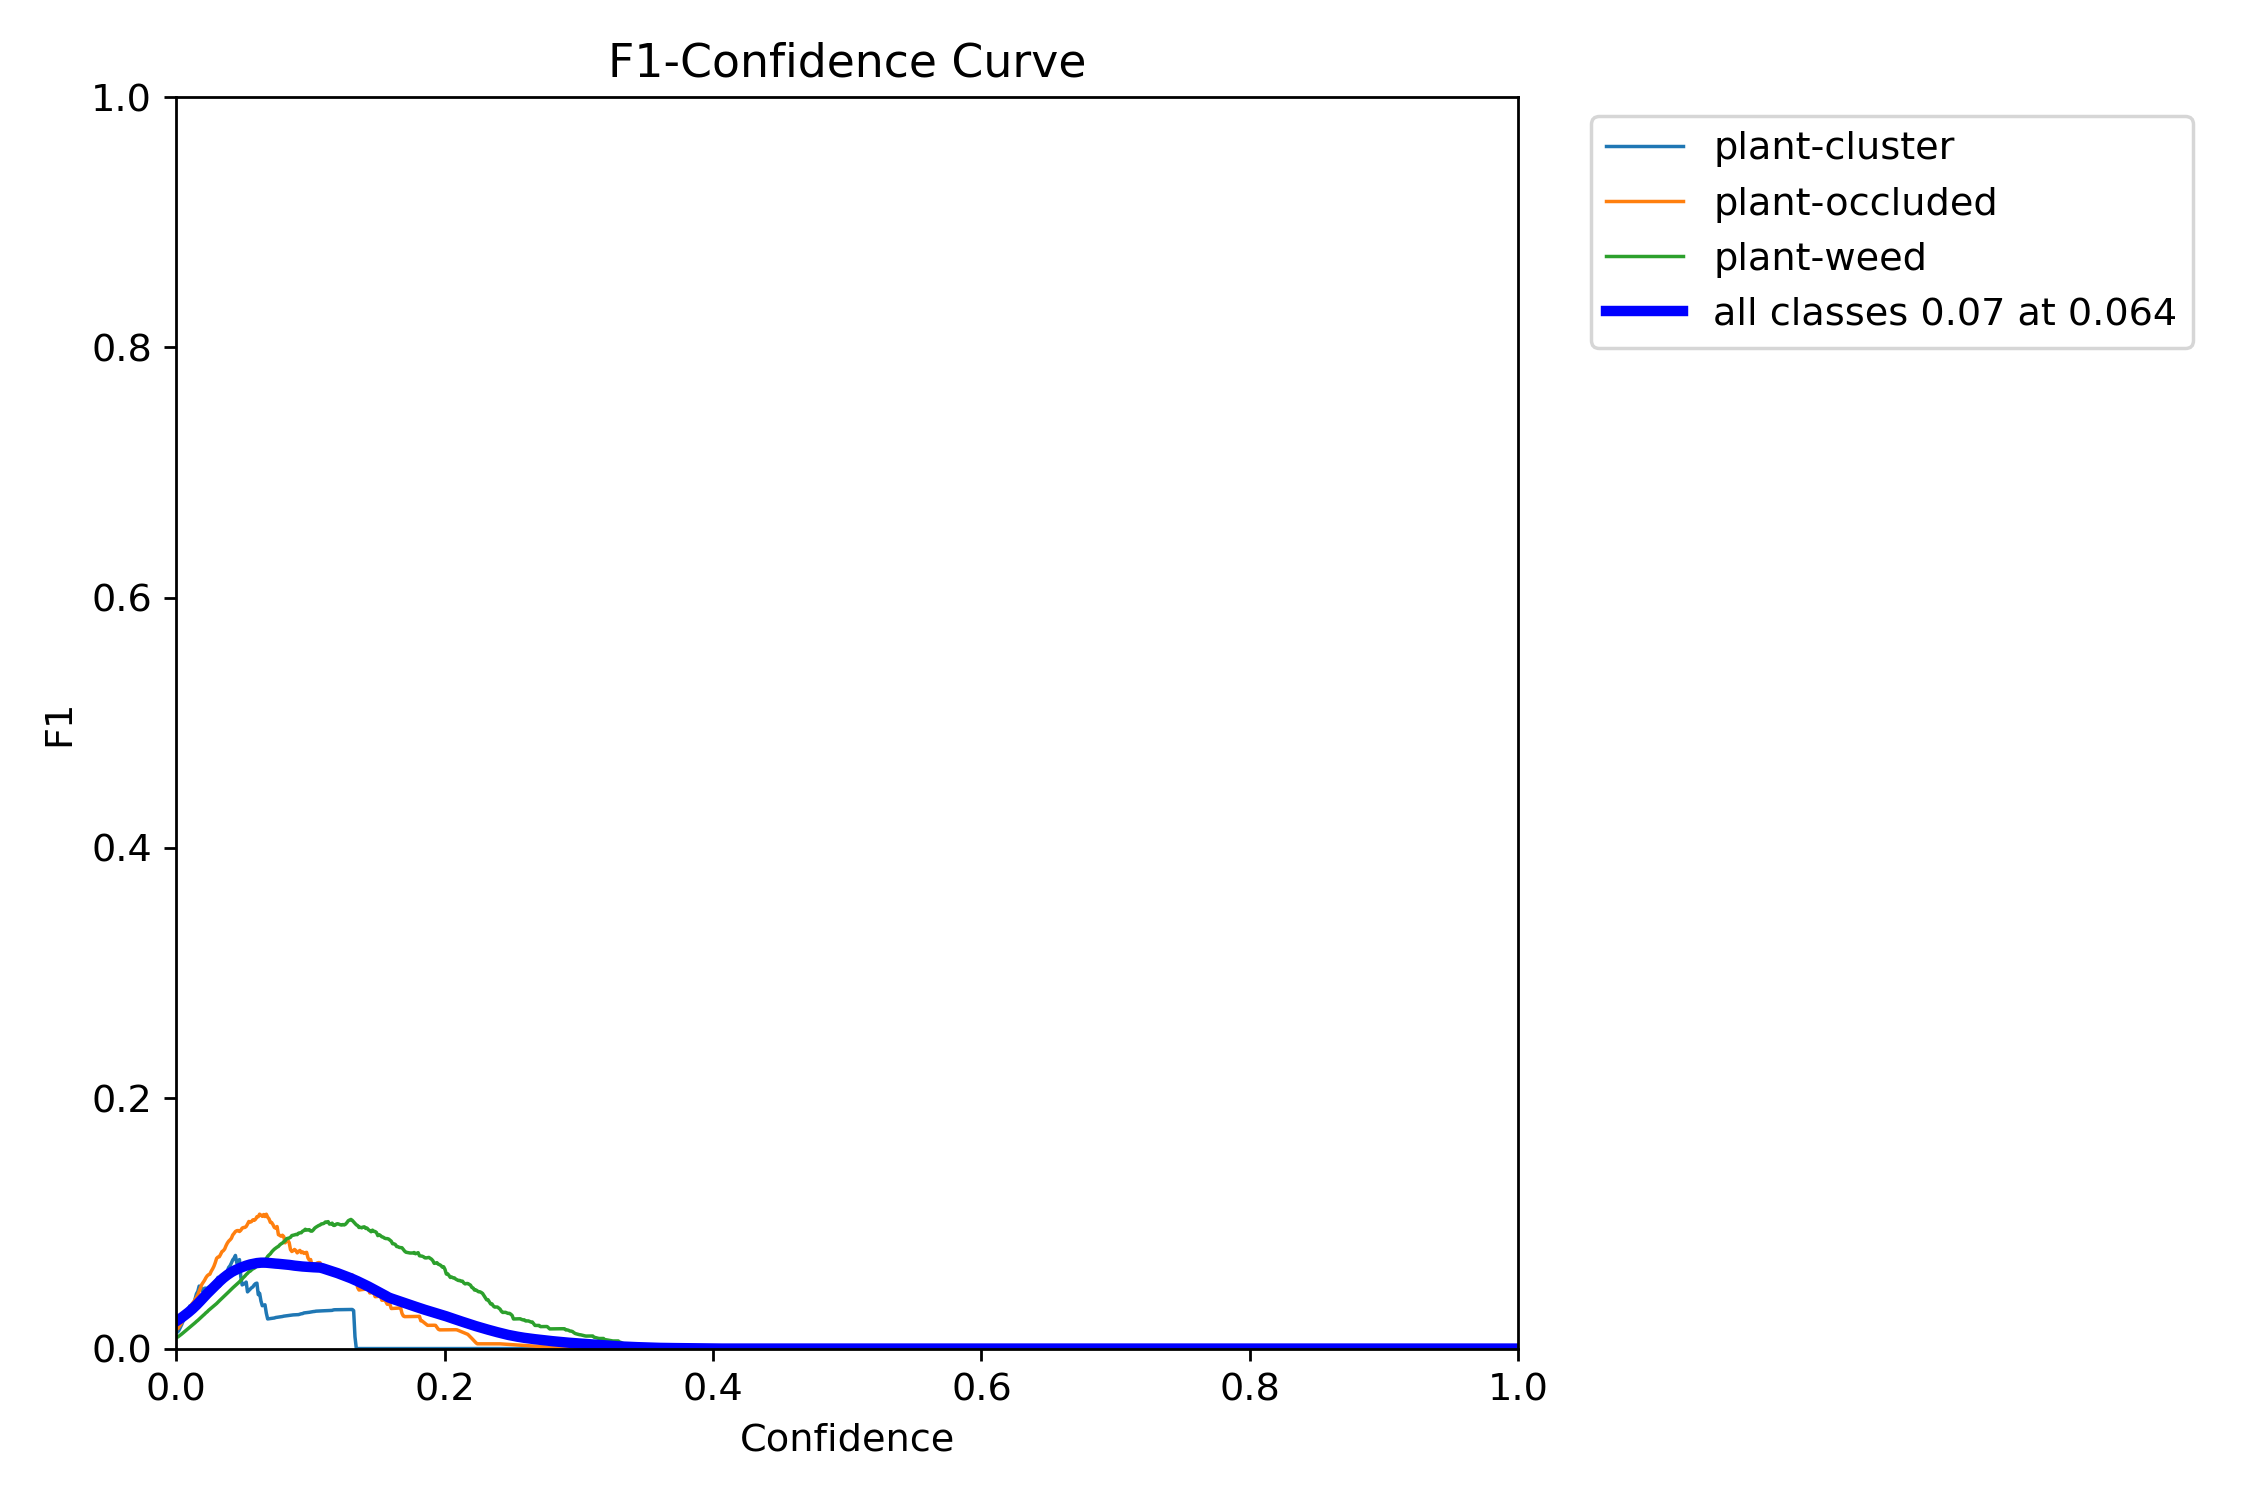

In [279]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

El valor de confianza que optimiza la precisión y recall es 0.231. En la mayoría de los casos, una mayor confianza es deseable.

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

----

## Experiment 8 *(small weed)*
### *5m | 90º | small*

In [280]:
folder = "train2/"

In [281]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df2 = pd.read_csv(file_path)
df = df2.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
95,96,628.645,2.78999,2.00942,1.38745,0.07944,0.09479,0.03597,0.00870,3.06361,3.23375,1.48477,0.000085,0.000085,0.000085
96,97,635.405,2.79593,2.02462,1.39337,0.07821,0.08949,0.03439,0.00844,3.06898,3.24353,1.48646,0.000071,0.000071,0.000071
97,98,641.083,2.79623,2.00122,1.37046,0.07625,0.09215,0.03465,0.00846,3.07012,3.29365,1.48560,0.000057,0.000057,0.000057
98,99,647.591,2.82190,2.00674,1.38671,0.07756,0.09173,0.03507,0.00836,3.07671,3.30916,1.48753,0.000043,0.000043,0.000043
99,100,653.406,2.77292,2.00540,1.37704,0.07576,0.09027,0.03446,0.00844,3.08032,3.30521,1.49012,0.000028,0.000028,0.000028


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [282]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 10.890 min


#### Best epoch

In [283]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
36,37,249.075,3.05612,2.11753,1.41037,0.07591,0.09076,0.03722,0.00968,3.05066,3.7909,1.48528,0.00092,0.00092,0.00092,10.8901


In [284]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 37 con mAP50 de 0.037


In [285]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [286]:
TP = 21+6+5+52
FP = 65+198
FN = 1697+366
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 2410


In [287]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.034854771784232366, 0.10912863070539419, 0.8560165975103734)

### Graphs

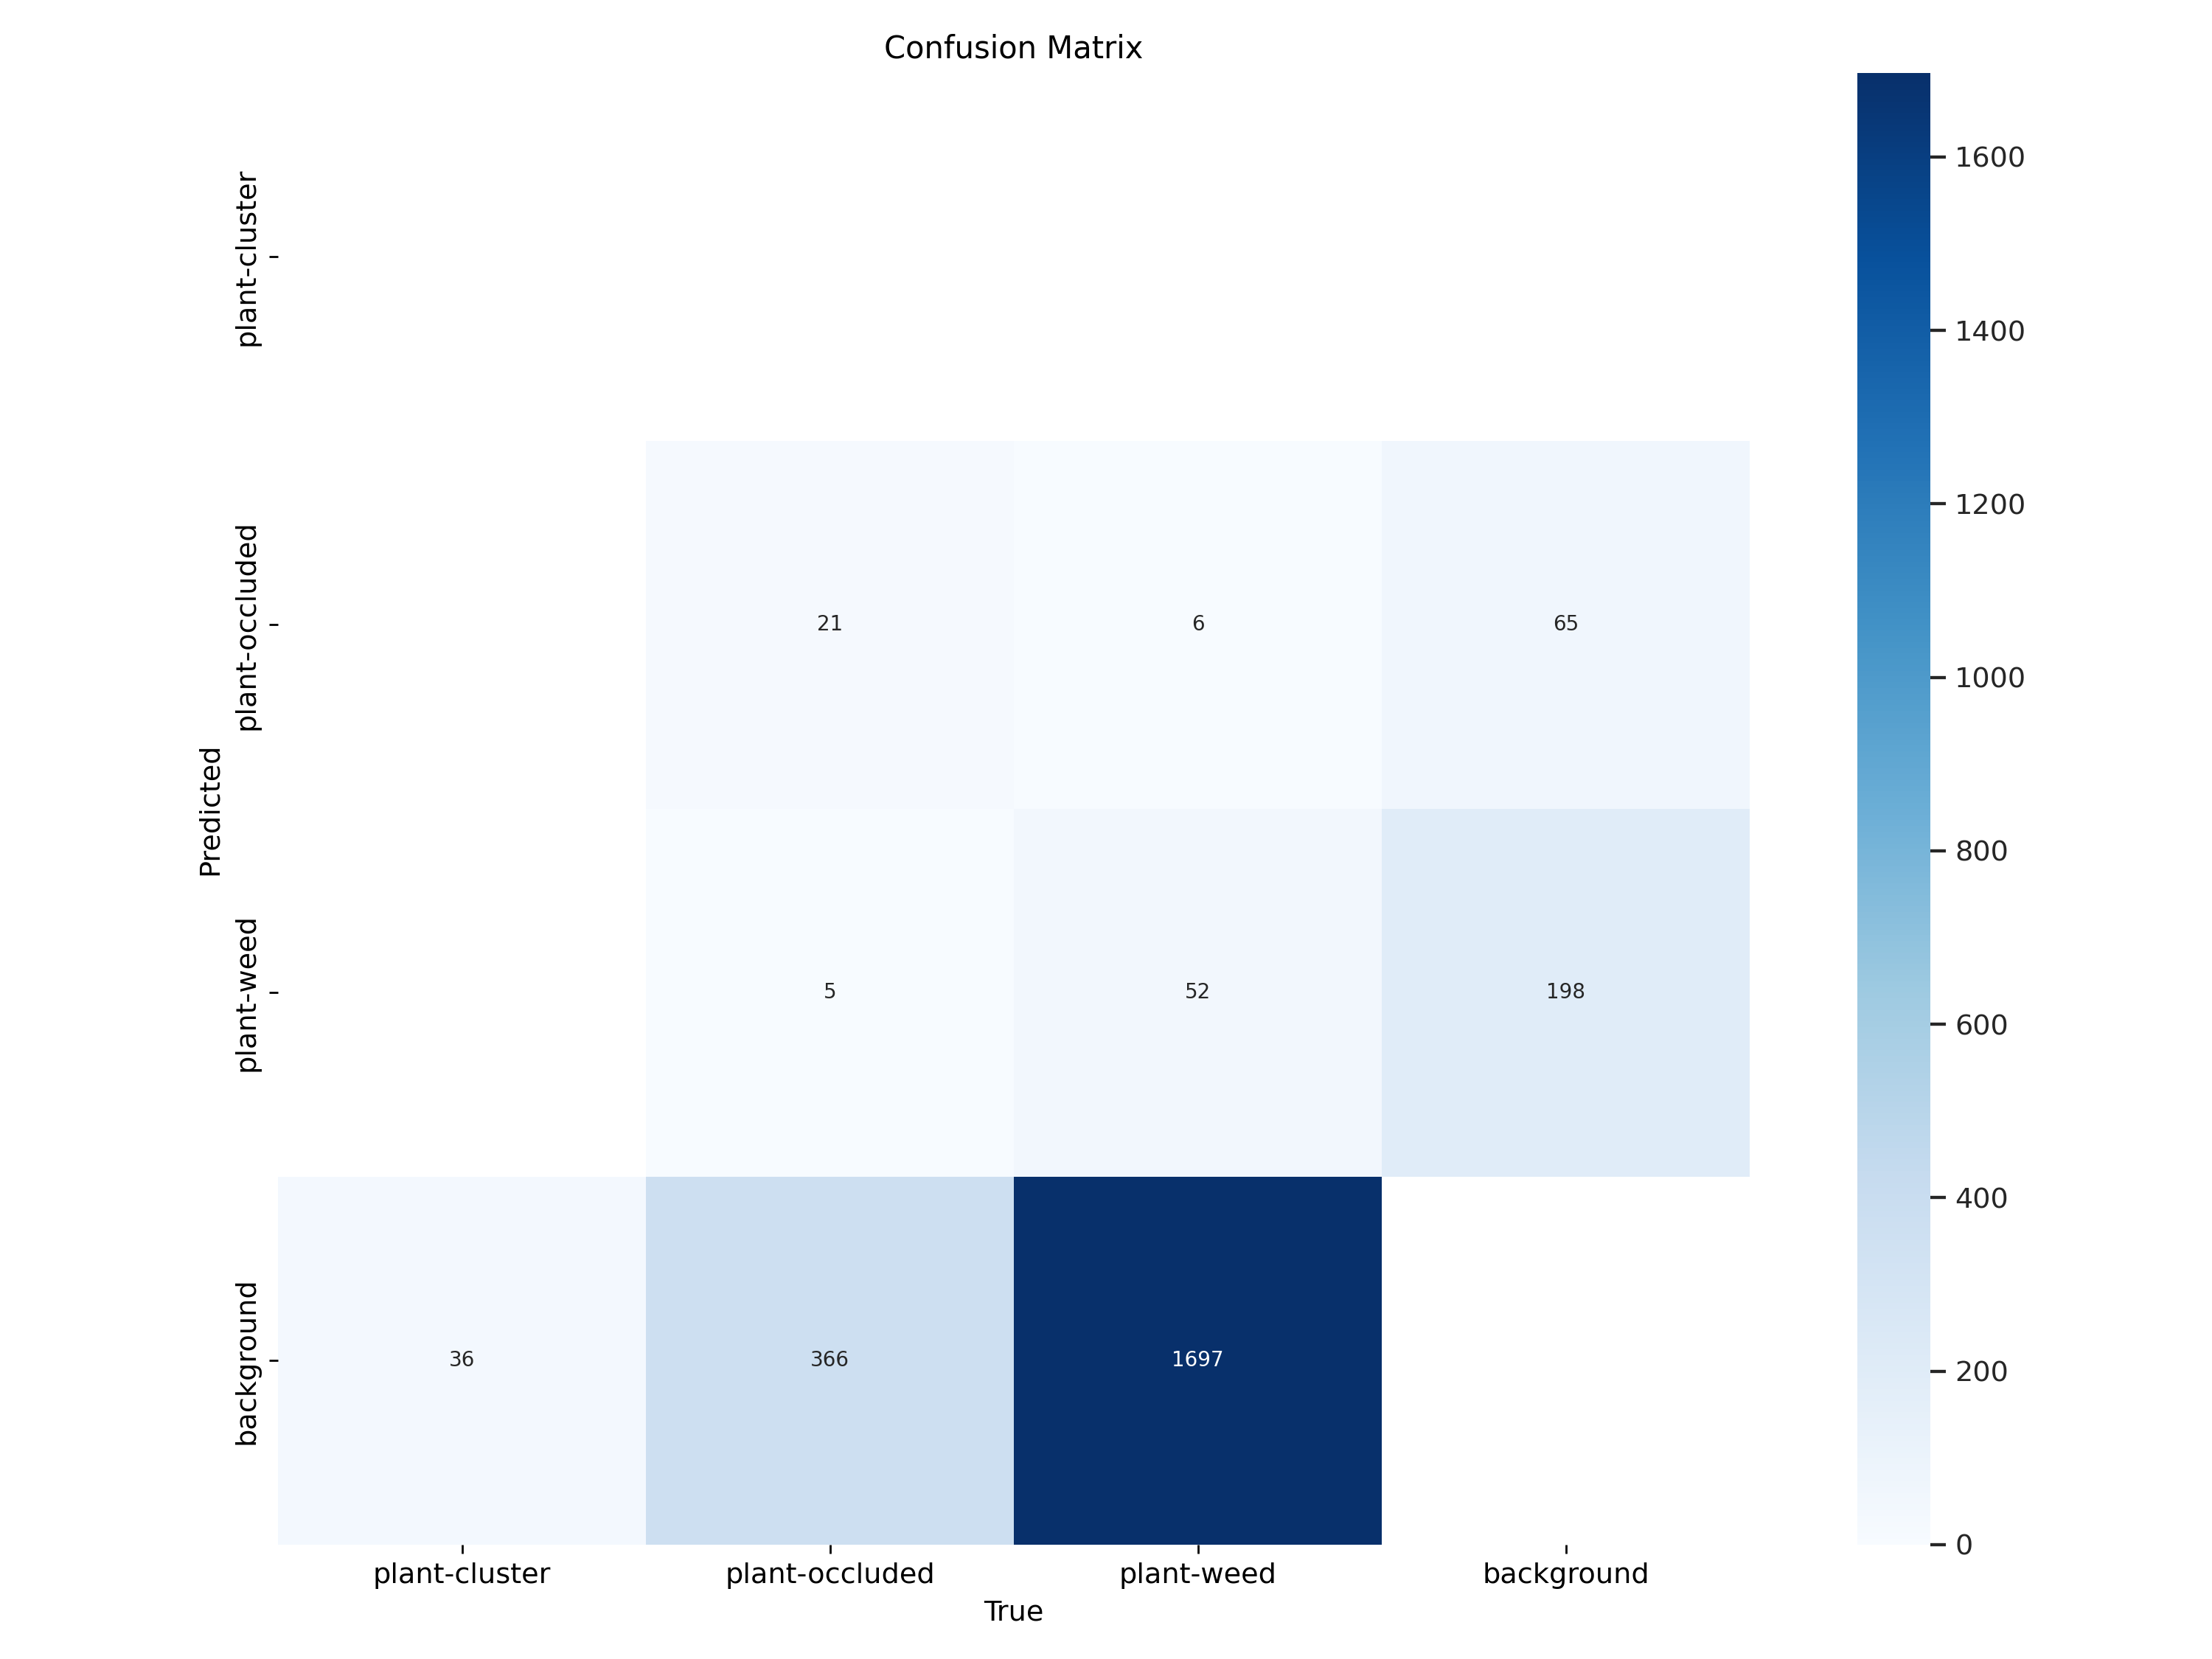

In [288]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

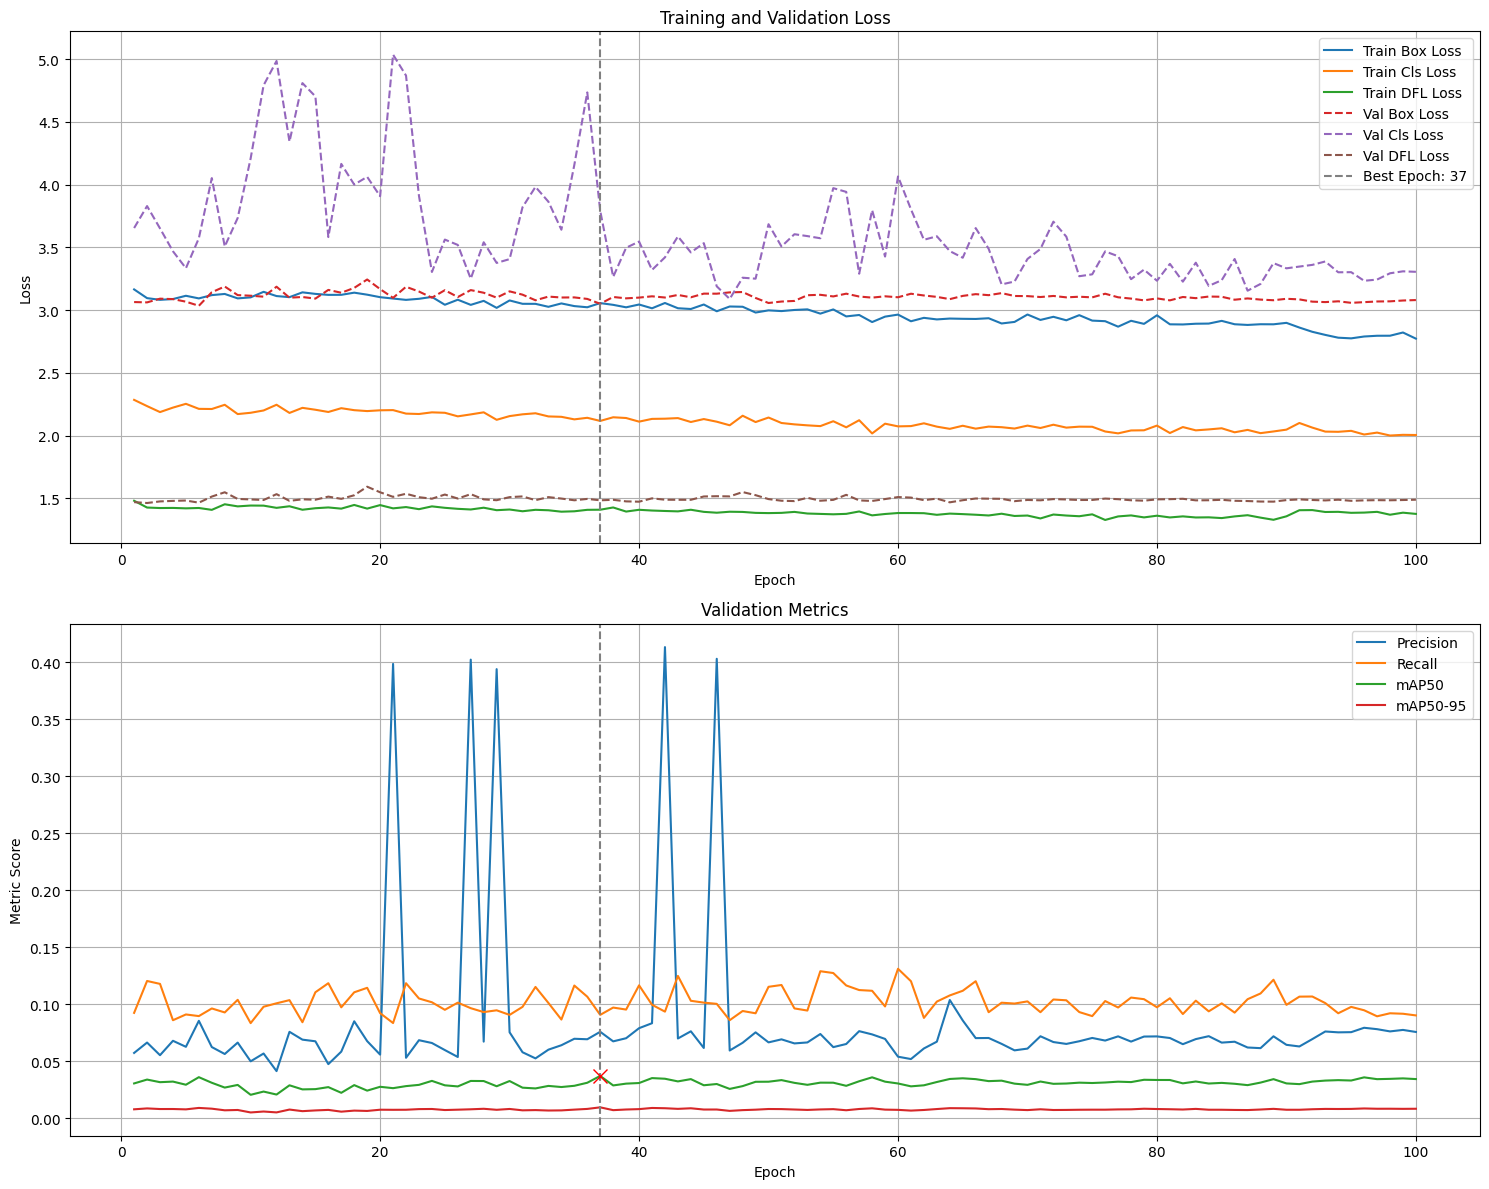

In [289]:
graph_training_metrics(df2, epoch, graph="full")

In [290]:
graph_LrLoss_3D(df2)

Validation set


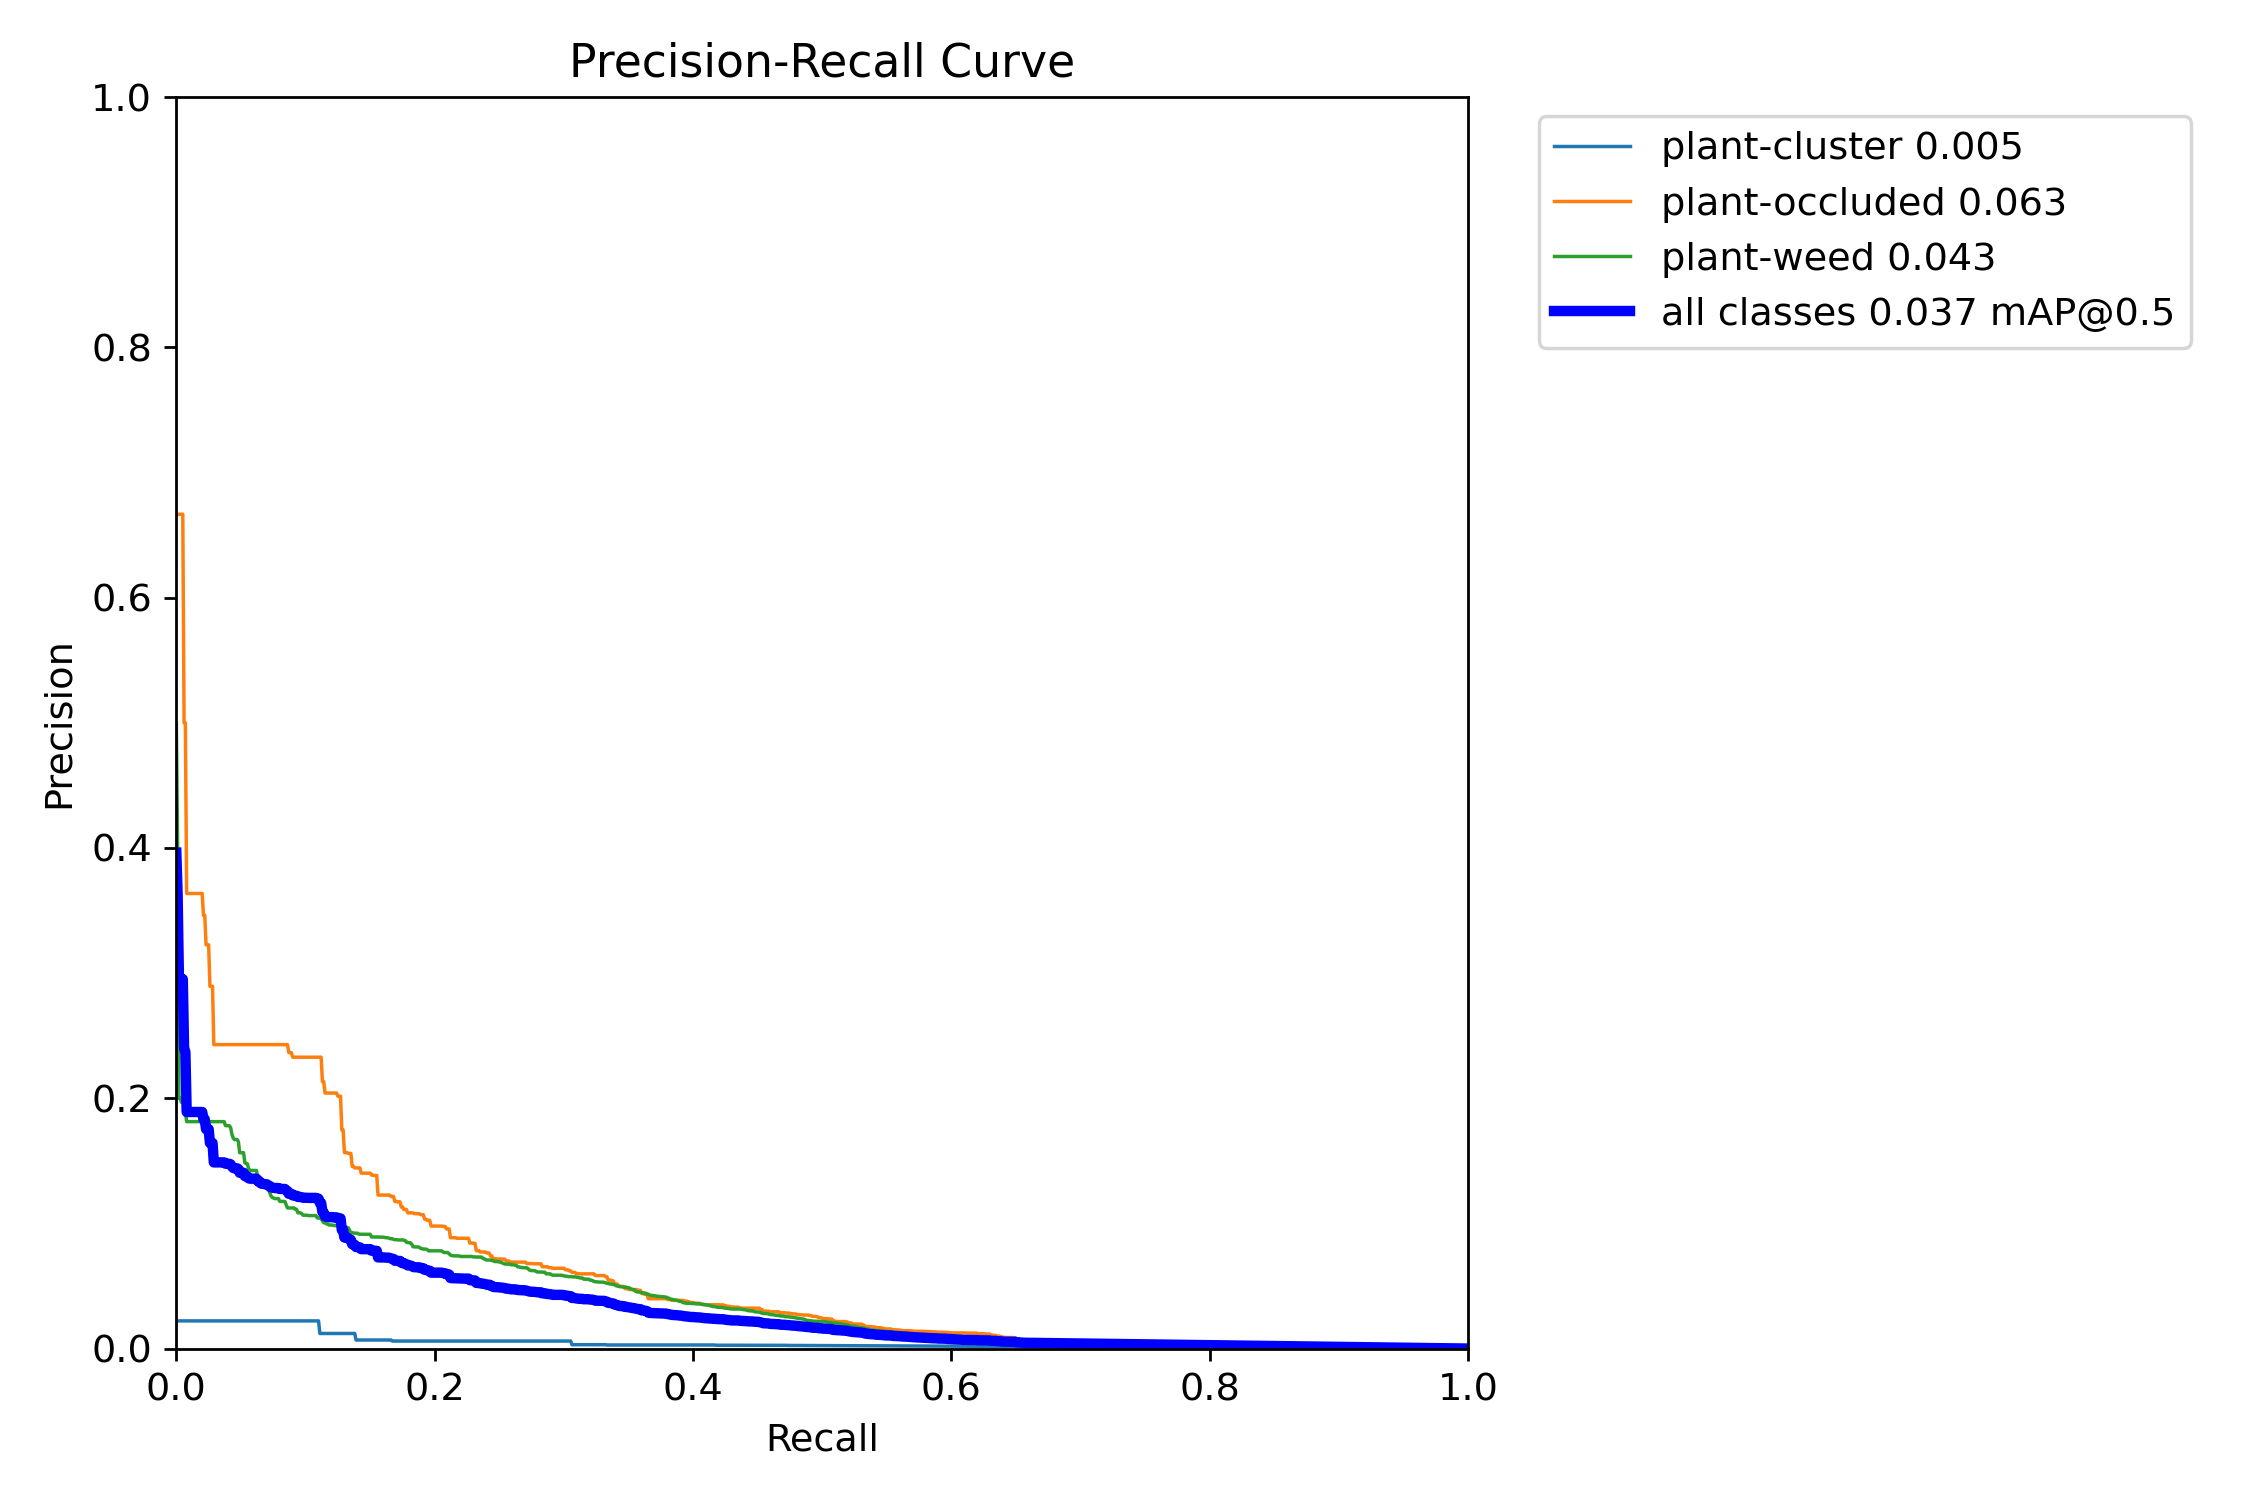

In [291]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

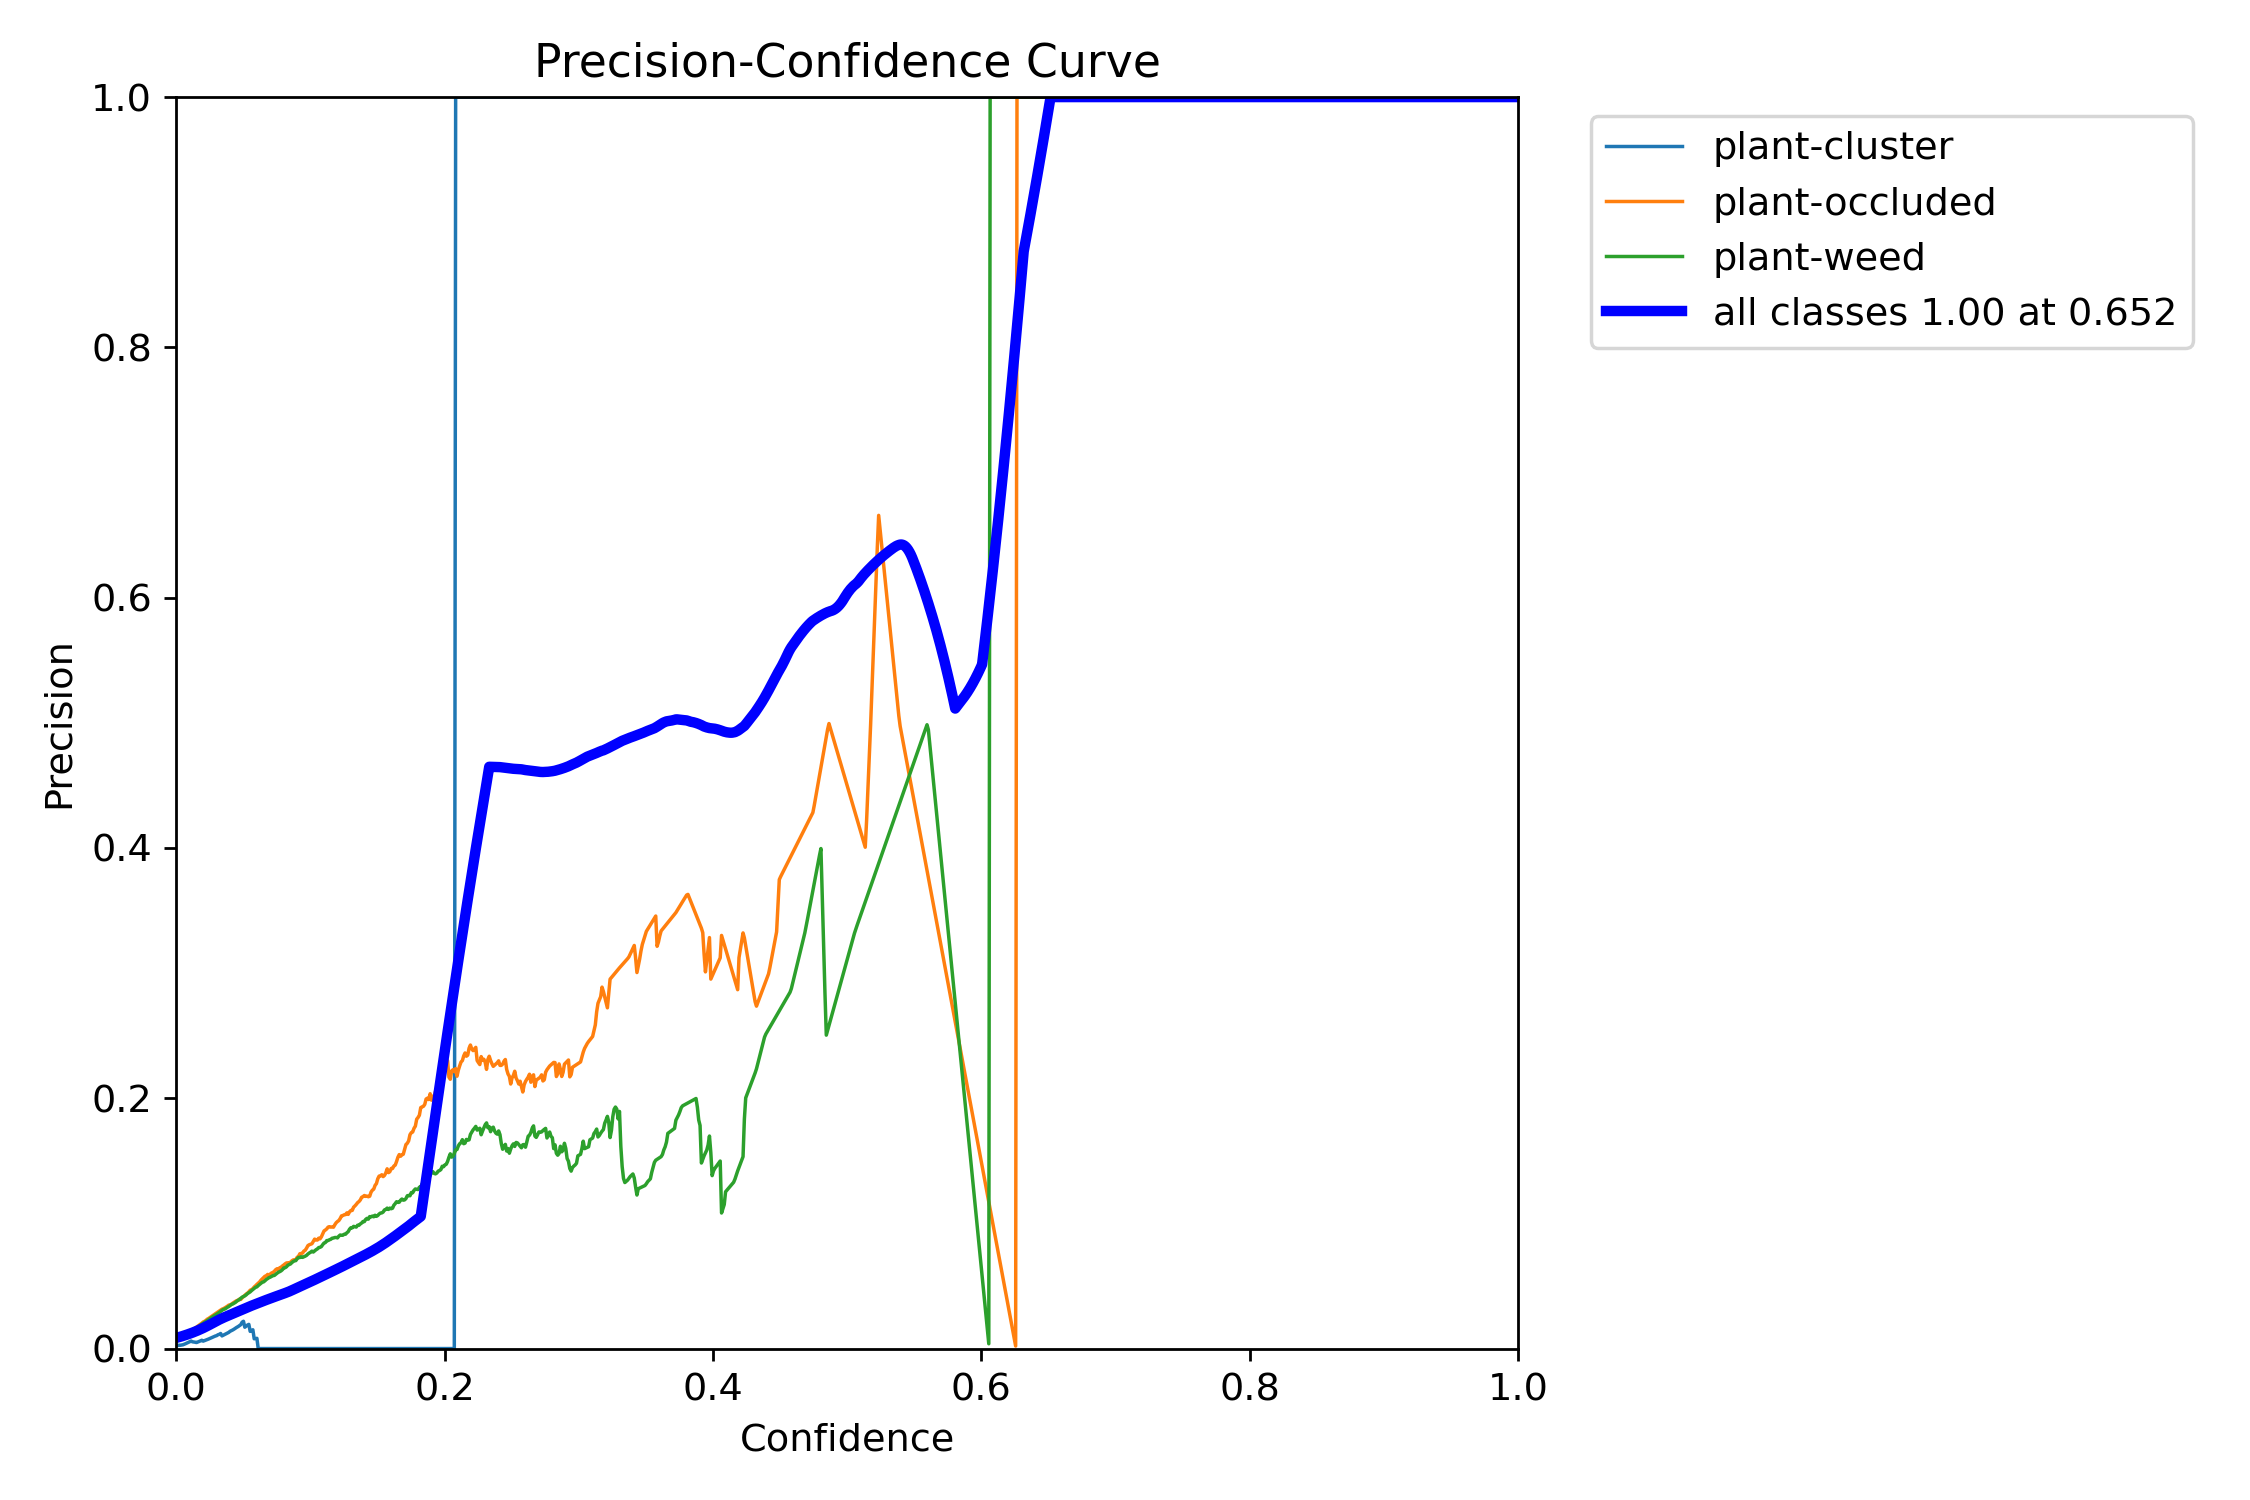

In [292]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

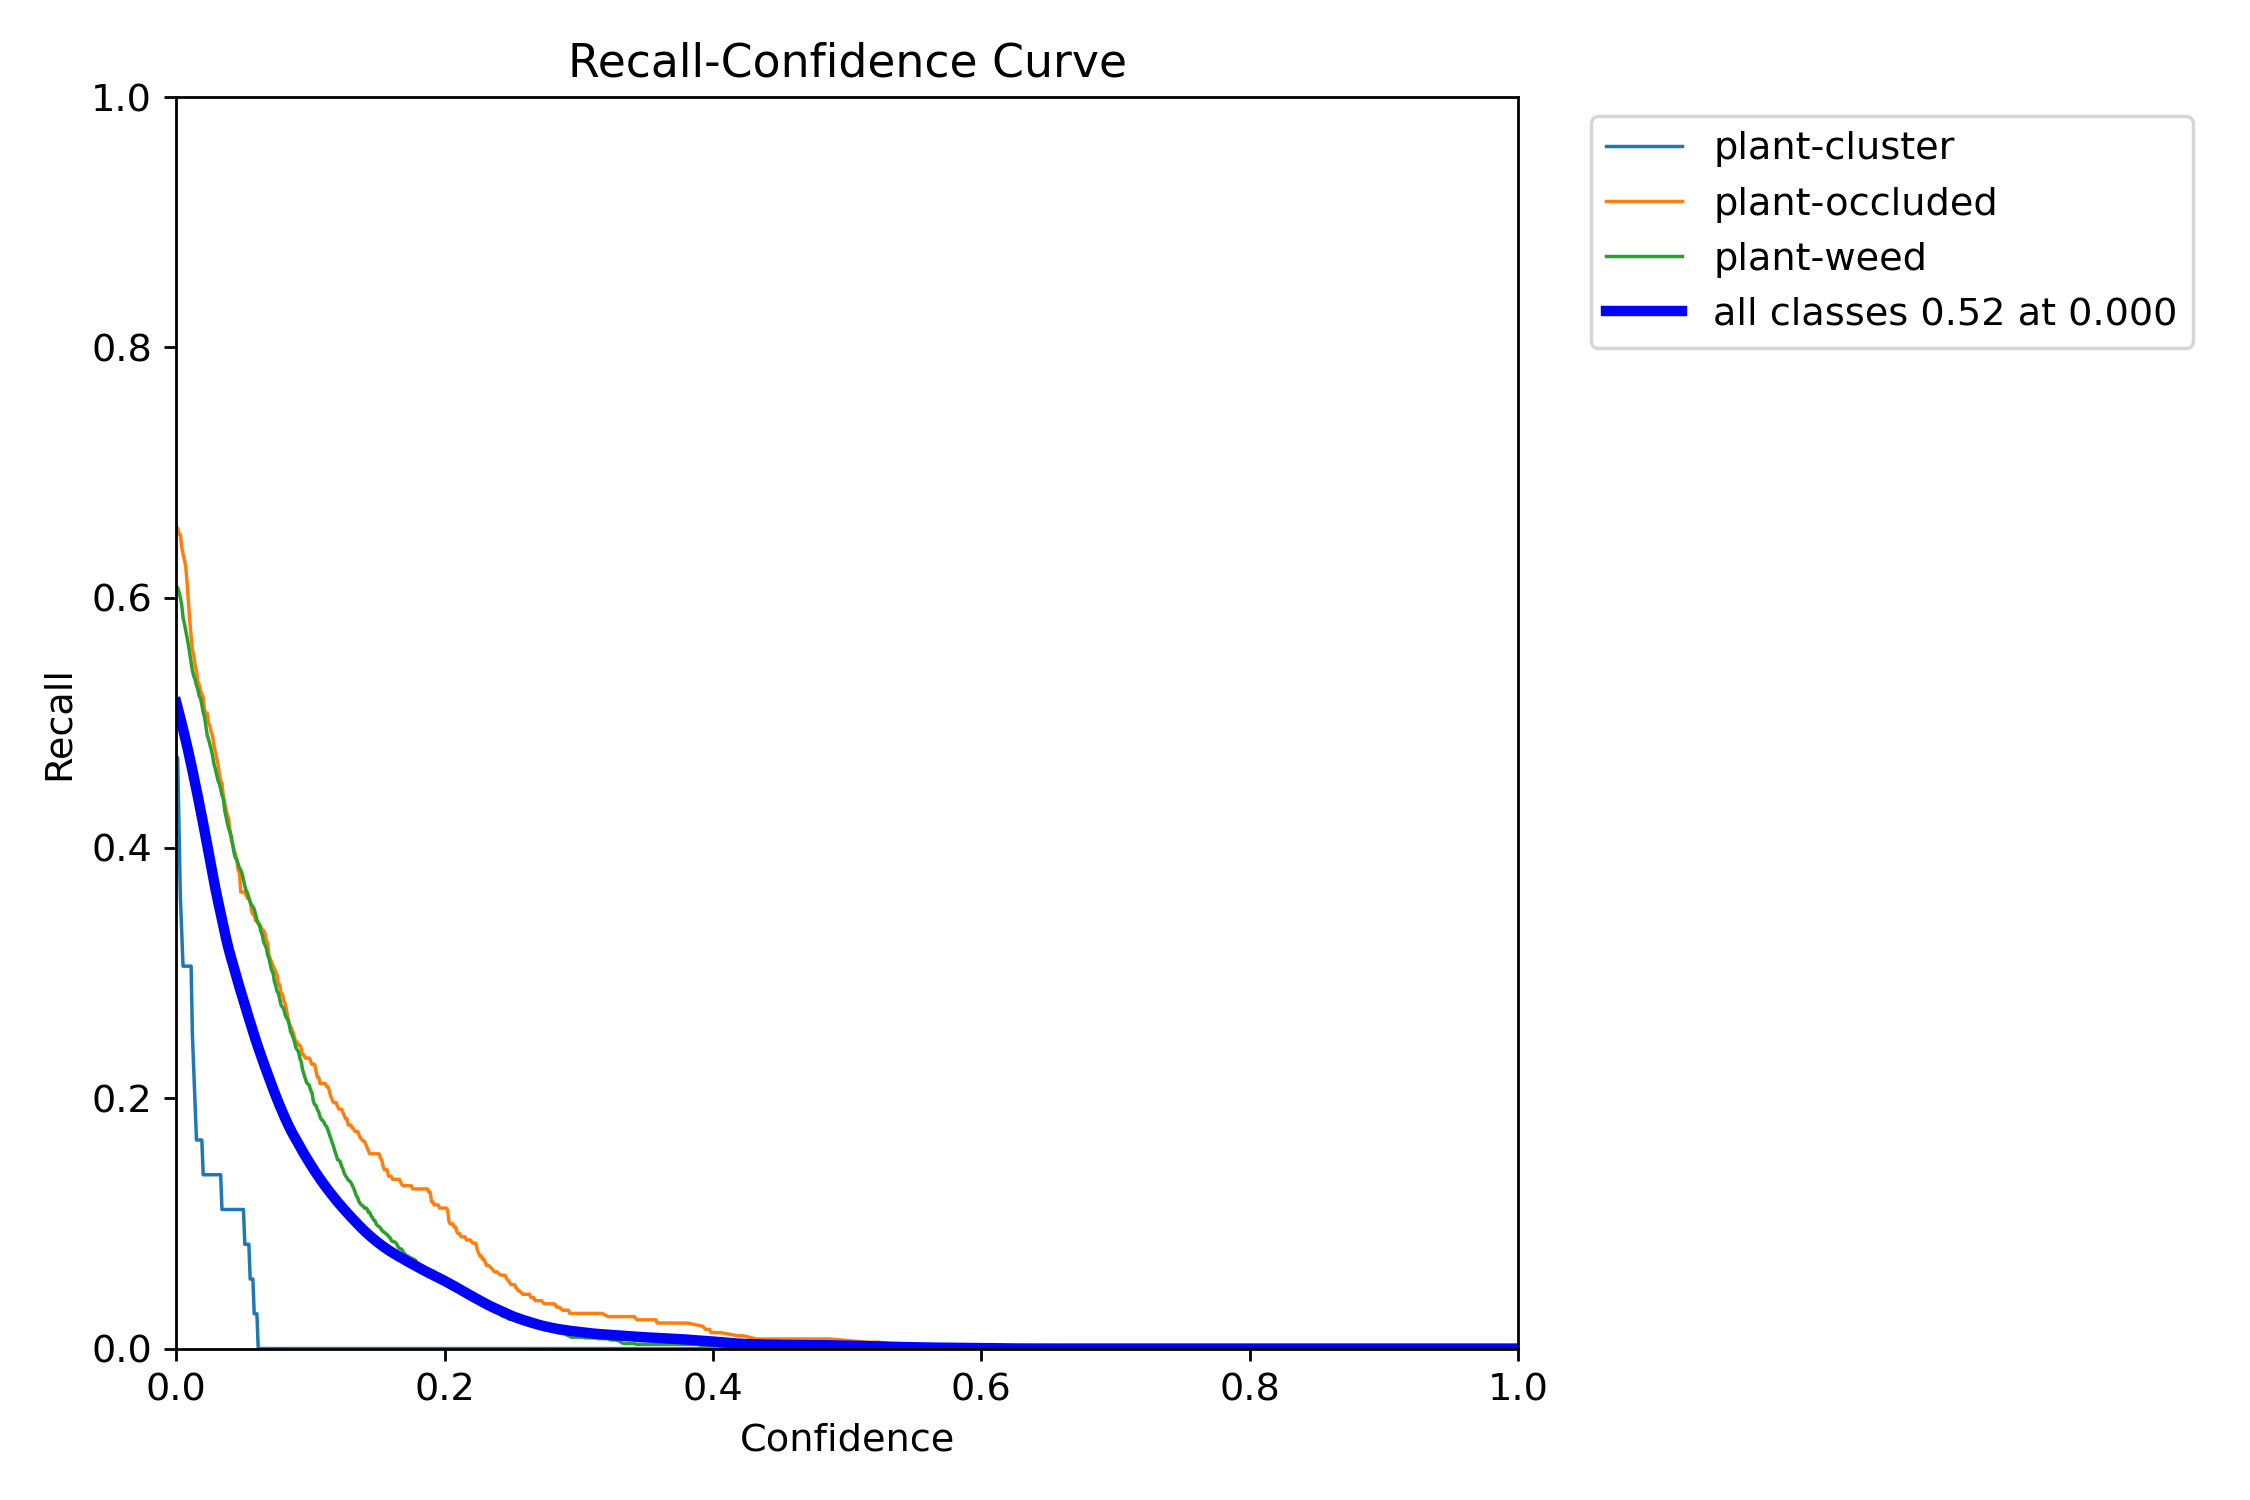

In [293]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

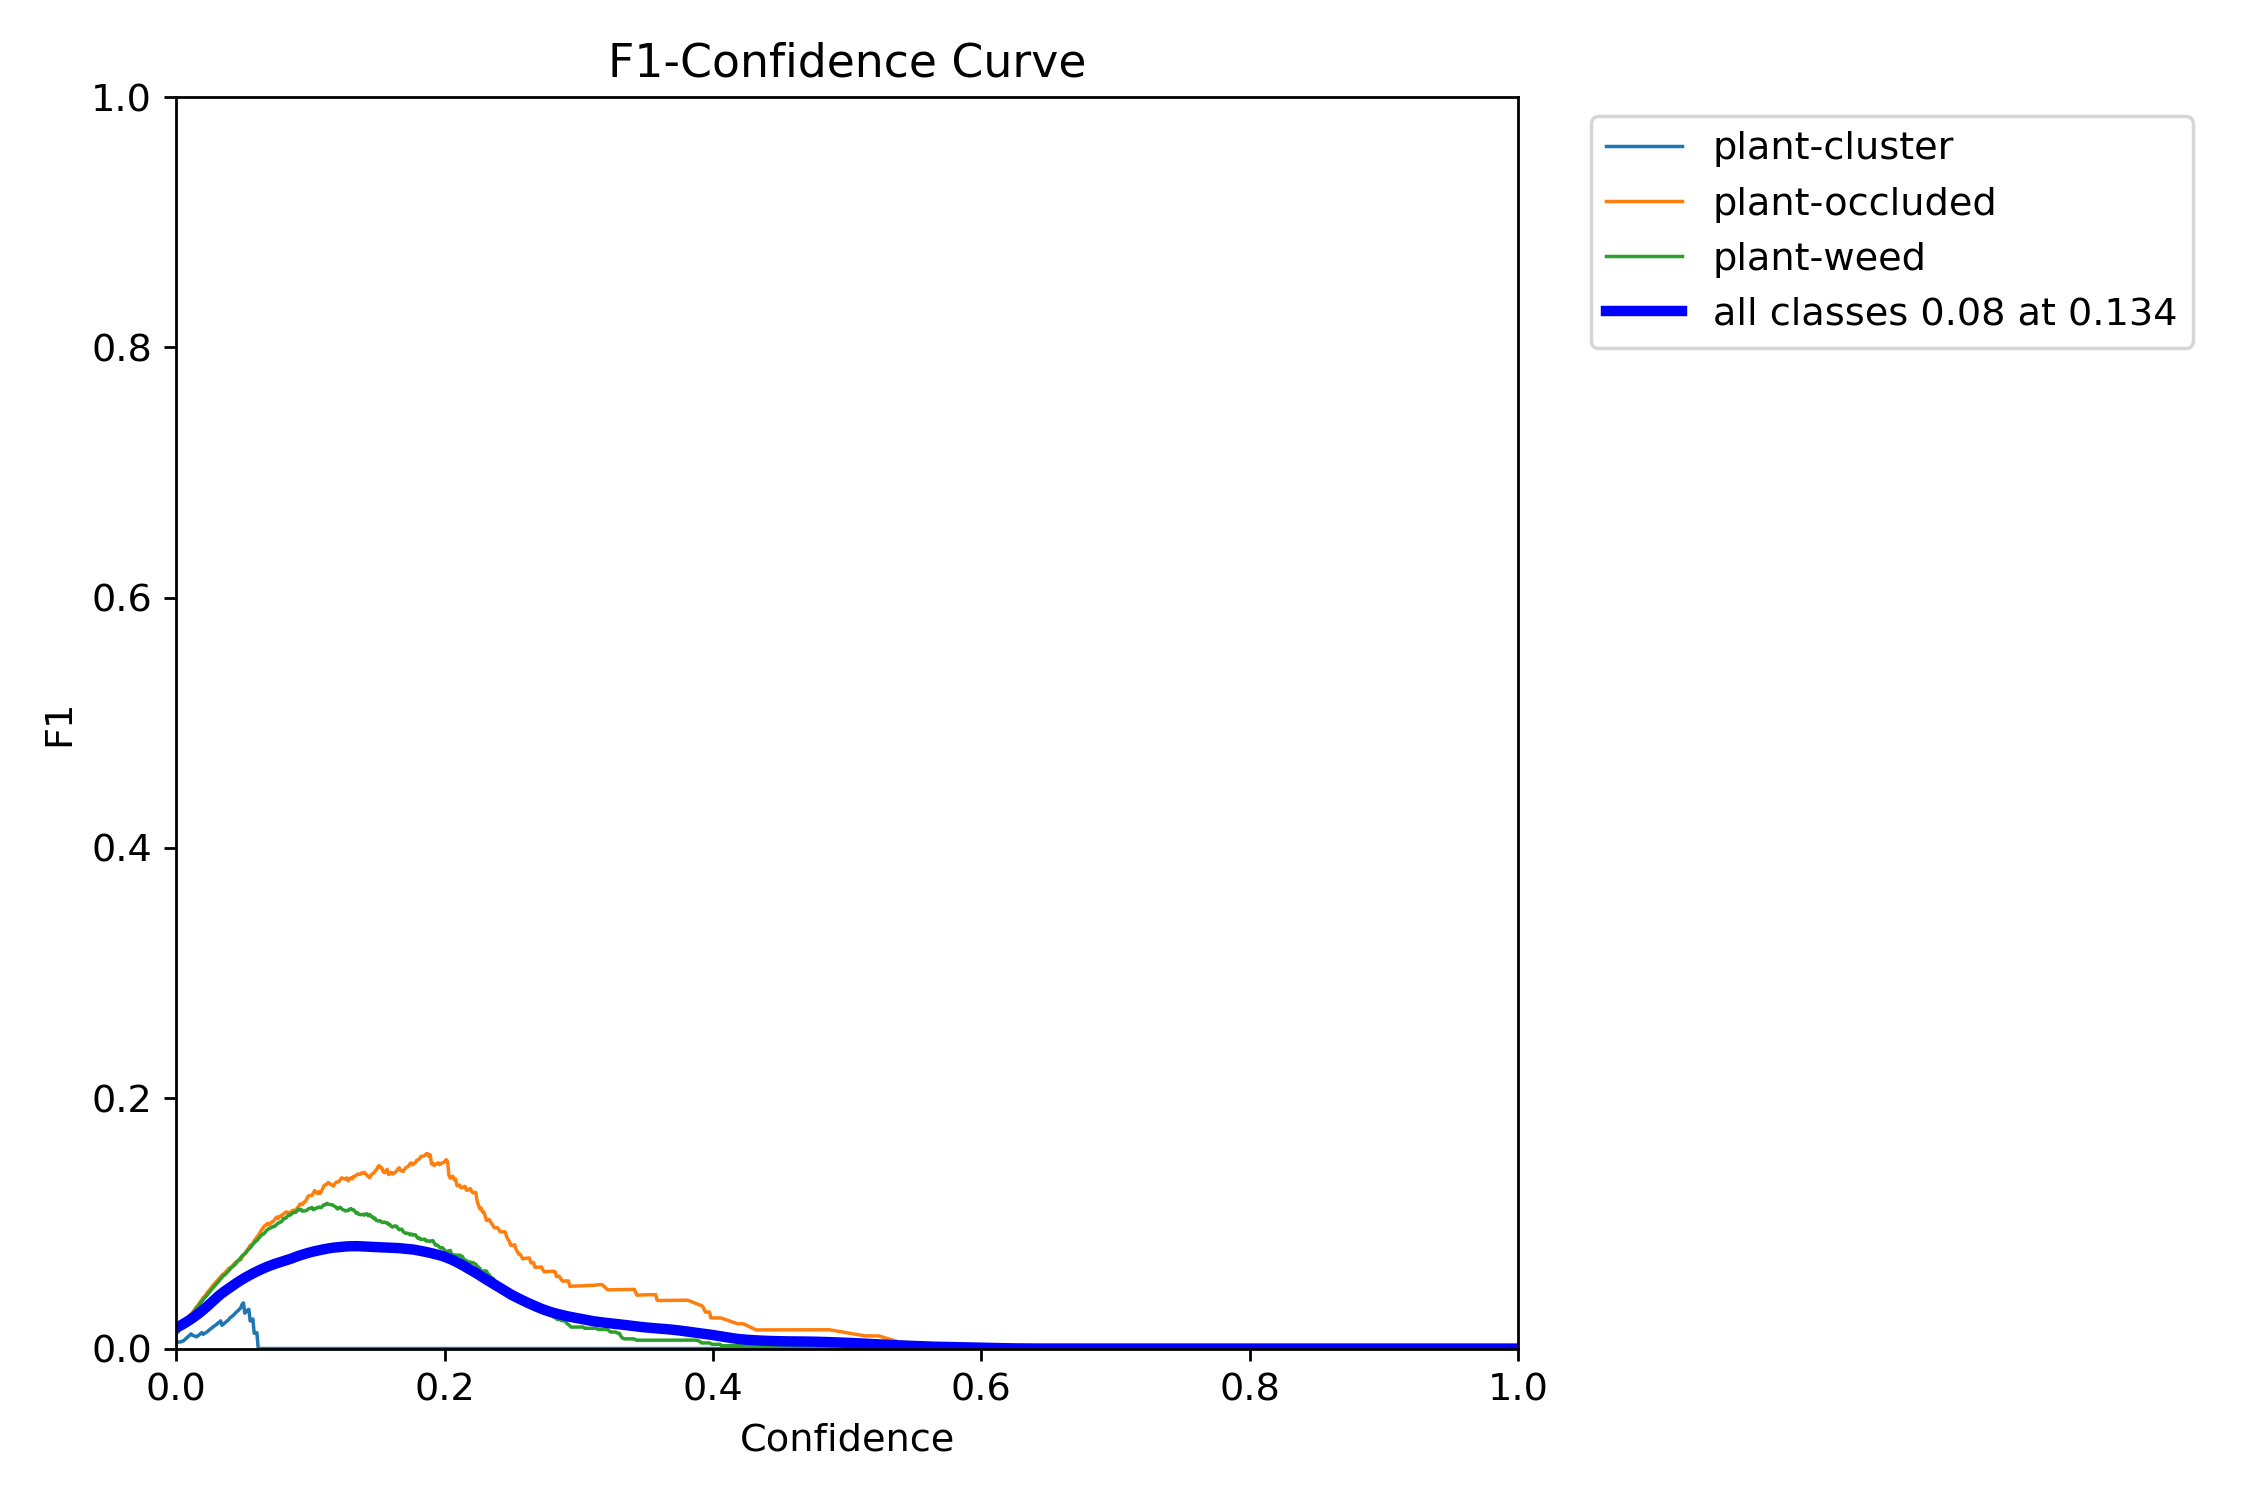

In [294]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

----

## Experiment 9 *(medium weed)*
### *5m | 90º | mid*

In [295]:
folder = "train3/"

In [296]:
# Ruta del archivo
file_path =  os.path.join(folder, "results.csv")

# Cargar el archivo en un DataFrame y mostrar las primeras filas
df3 = pd.read_csv(file_path)
df = df3.copy()
df.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
95,96,357.359,2.72253,2.04502,1.67177,0.07259,0.07551,0.02956,0.00806,1.98970,28.4150,1.20059,0.000085,0.000085,0.000085
96,97,361.238,2.70930,2.07205,1.63063,0.08884,0.06561,0.03045,0.00842,1.98935,28.0724,1.20118,0.000071,0.000071,0.000071
97,98,364.287,2.70266,2.06357,1.65101,0.07277,0.06349,0.03130,0.00845,1.99195,30.1254,1.19719,0.000057,0.000057,0.000057
98,99,367.314,2.69026,2.05693,1.67162,0.10656,0.06482,0.03285,0.00858,1.99434,32.6082,1.19615,0.000043,0.000043,0.000043
99,100,370.477,2.71467,2.02844,1.62872,0.10450,0.06812,0.03349,0.00859,1.99414,33.0044,1.19464,0.000028,0.000028,0.000028


***NOTE:***
- `lr/pg0` typically refers to the learning rate for the backbone weights.
- `lr/pg1` is usually associated with the learning rate for the YOLO layers' weights.
- `lr/pg2` often represents the learning rate for any additional parameters, such as biases.

In [297]:
last_row = df.iloc[-1]
time = last_row['time']/60
print(f"Training time: {time:.3f} min")

Training time: 6.175 min


#### Best epoch

In [298]:
best = df[df['metrics/mAP50(B)'] == df['metrics/mAP50(B)'].max()].sort_values(by='epoch', ascending=True).head(1)
best['train_time'] = time
best

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
64,65,243.408,2.8186,2.04292,1.6235,0.19256,0.07203,0.05199,0.01247,2.11288,53.8067,1.2299,0.000524,0.000524,0.000524,6.174617


In [299]:
epoch = best['epoch'].values.astype(int)[0]
mAP50 = best['metrics/mAP50(B)'].values.astype(float)[0]
print(f"Mejor época de entrenamiento {epoch} con mAP50 de {mAP50:.3f}")

Mejor época de entrenamiento 65 con mAP50 de 0.052


In [300]:
if not best_models.empty:
    best_models = pd.concat([best_models, best], ignore_index=True)
else:
    best_models = best.copy().reset_index().drop(columns='index')

#### Classification metrics

In [301]:
TP = 27+5+1+1
FP = 100+6
FN = 172+127
base = TP+FP+FN
print("Total de objetos detectados:", base)

Total de objetos detectados: 439


In [302]:
# Cálculo de porcentajes
TP/base, FP/base, FN/base

(0.0774487471526196, 0.24145785876993167, 0.6810933940774487)

### Graphs

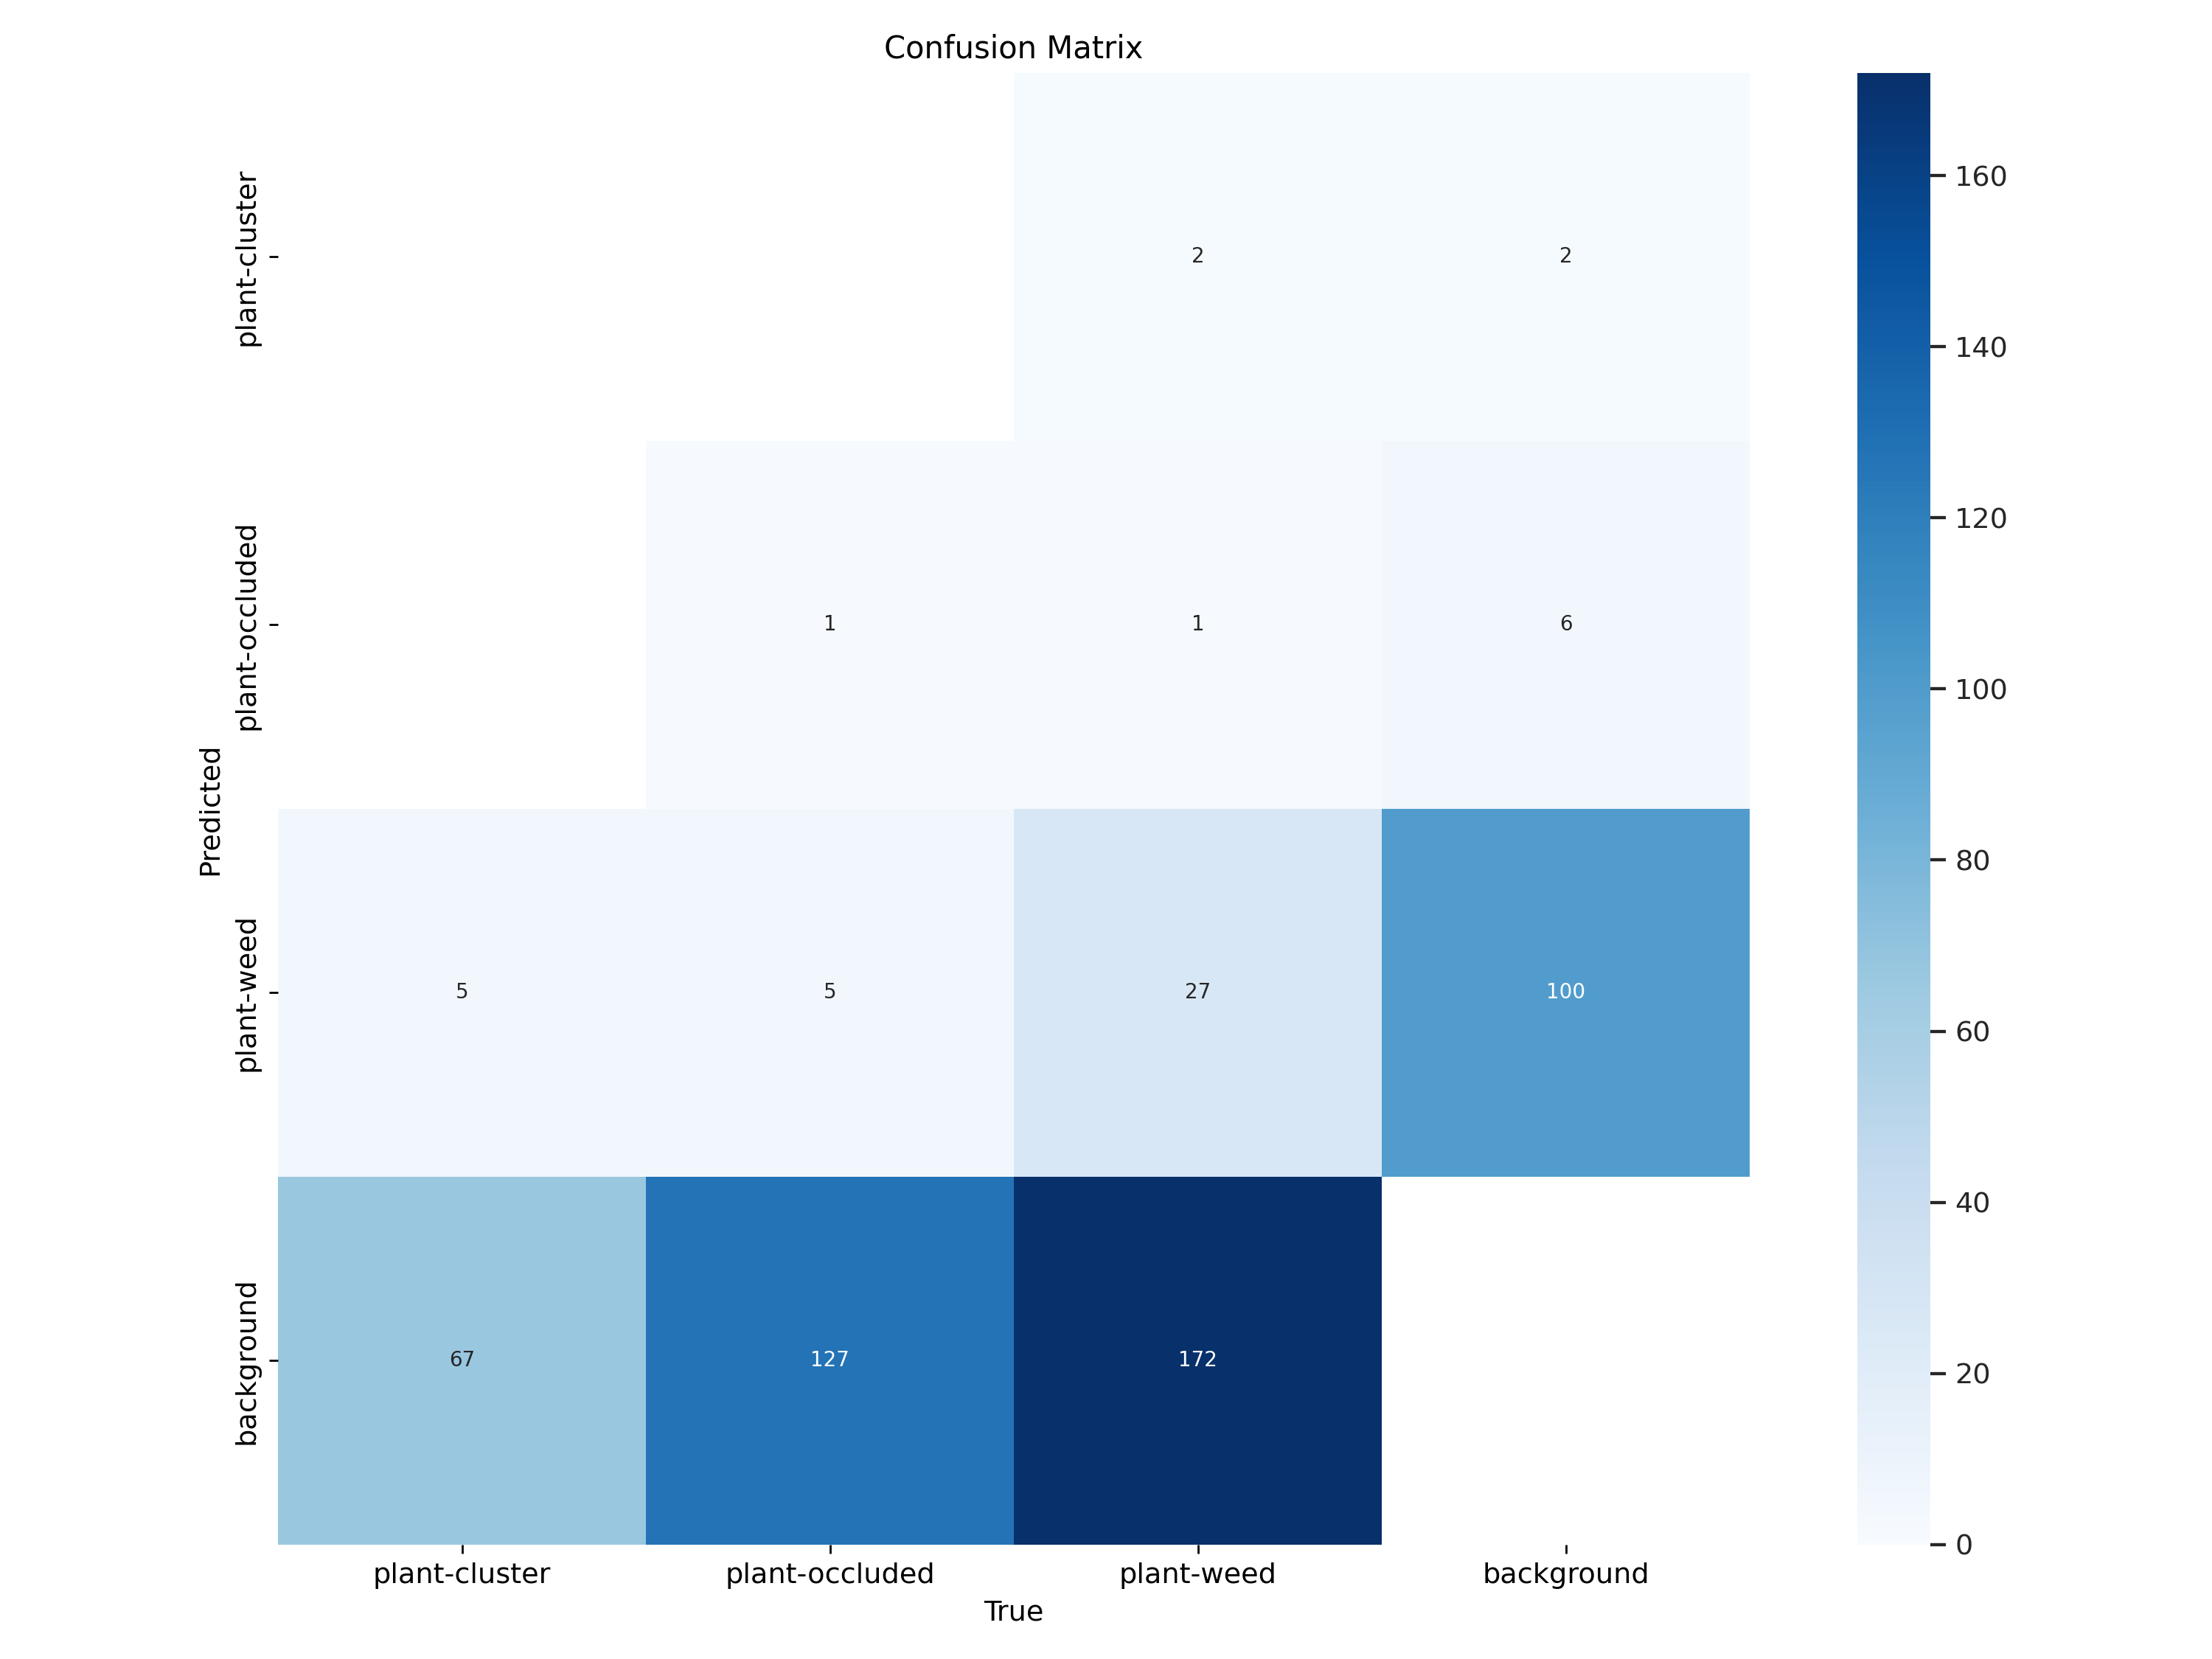

In [303]:
file_name = os.path.join(folder, "confusion_matrix.png")
Image(file_name, width=1000)

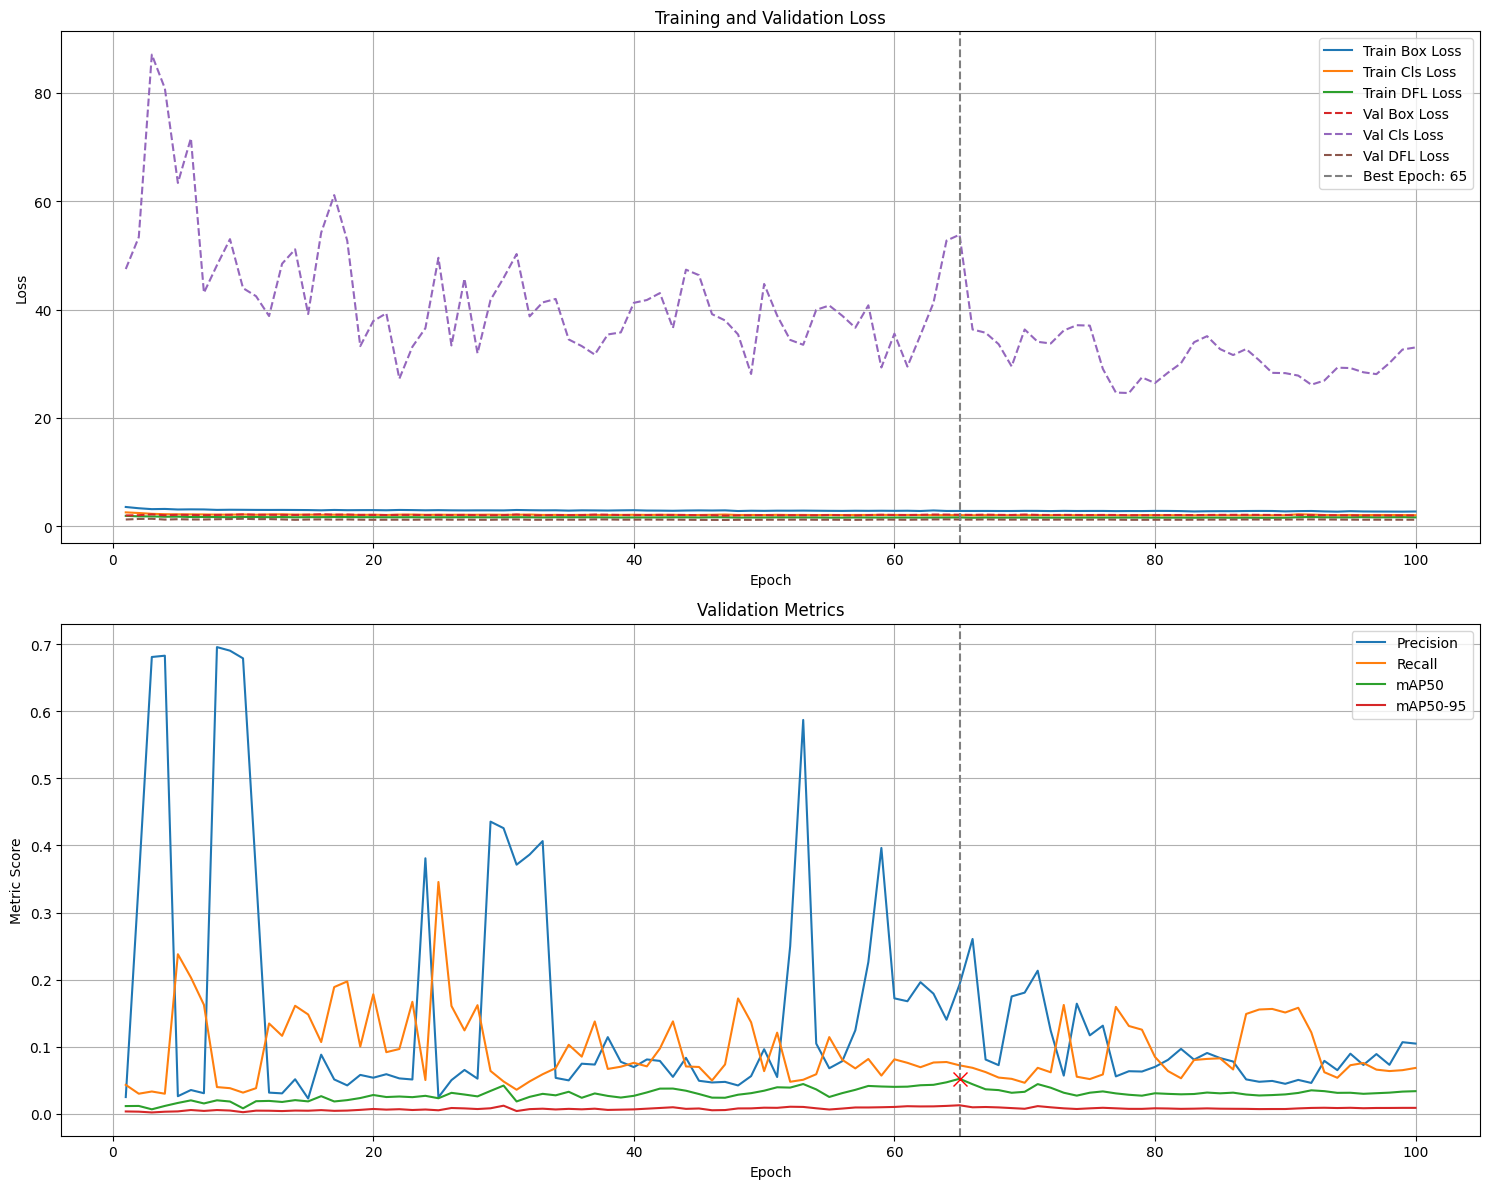

In [304]:
graph_training_metrics(df3, epoch, graph="full")

In [305]:
graph_LrLoss_3D(df3)

Validation set


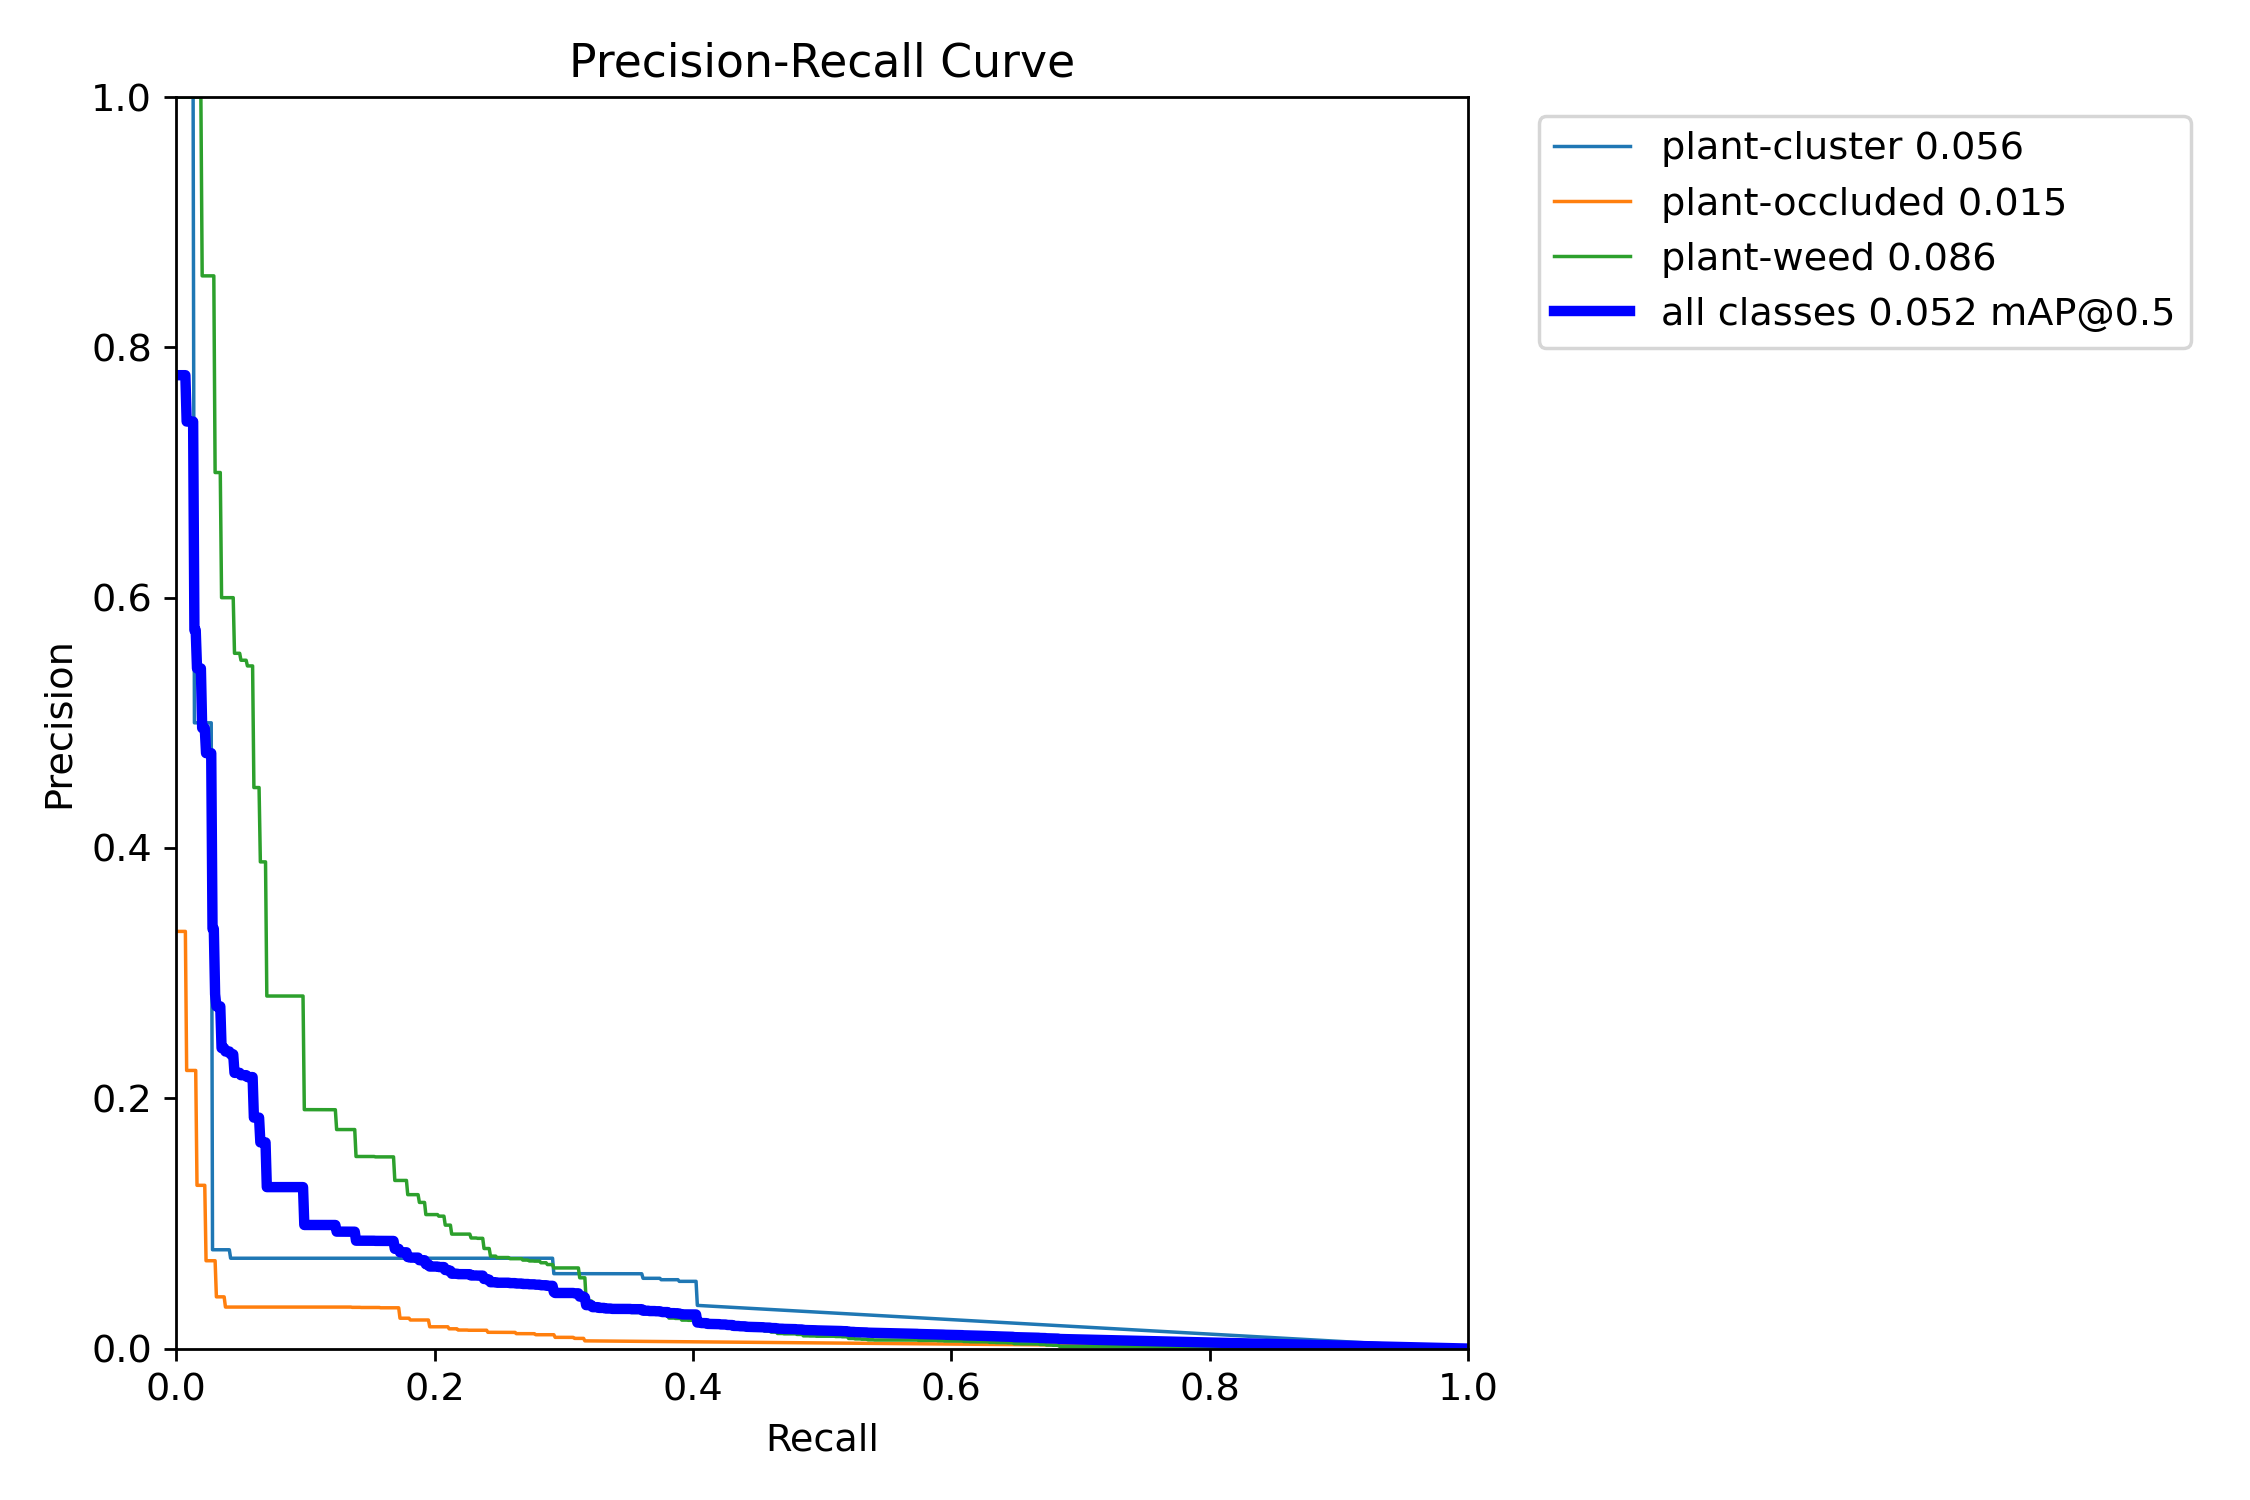

In [306]:
file_name = os.path.join(folder, "PR_curve.png")
Image(file_name, width=scale)

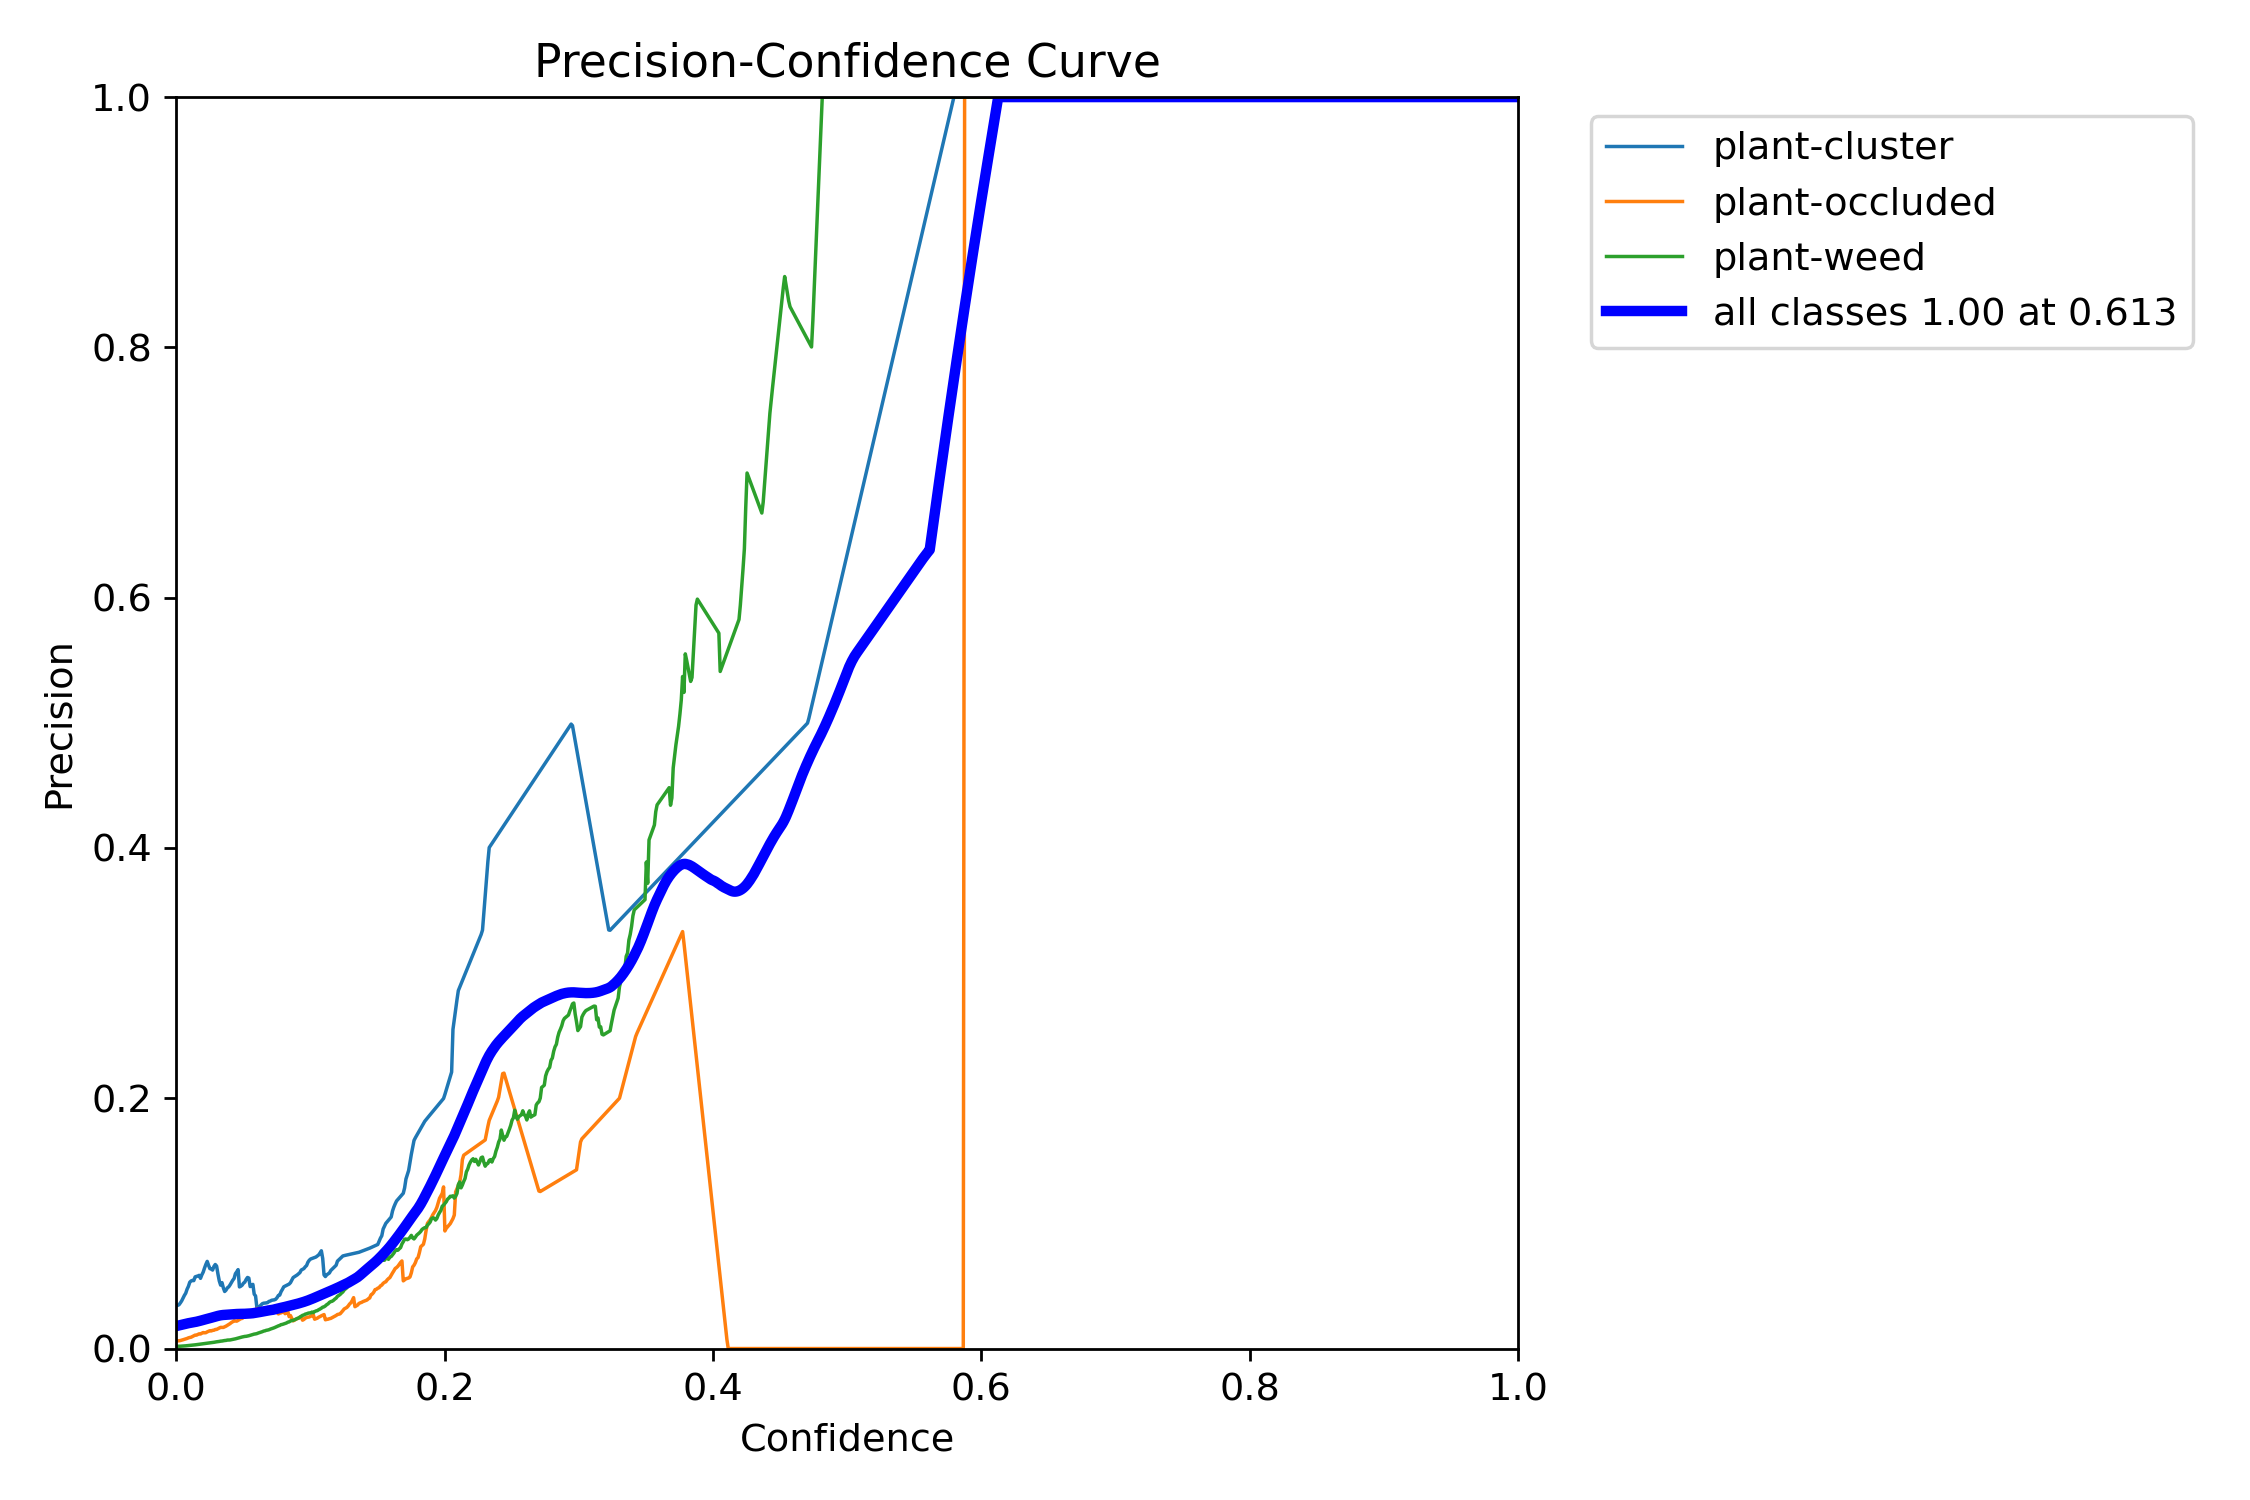

In [307]:
file_name = os.path.join(folder, "P_curve.png")
Image(file_name, width=scale)

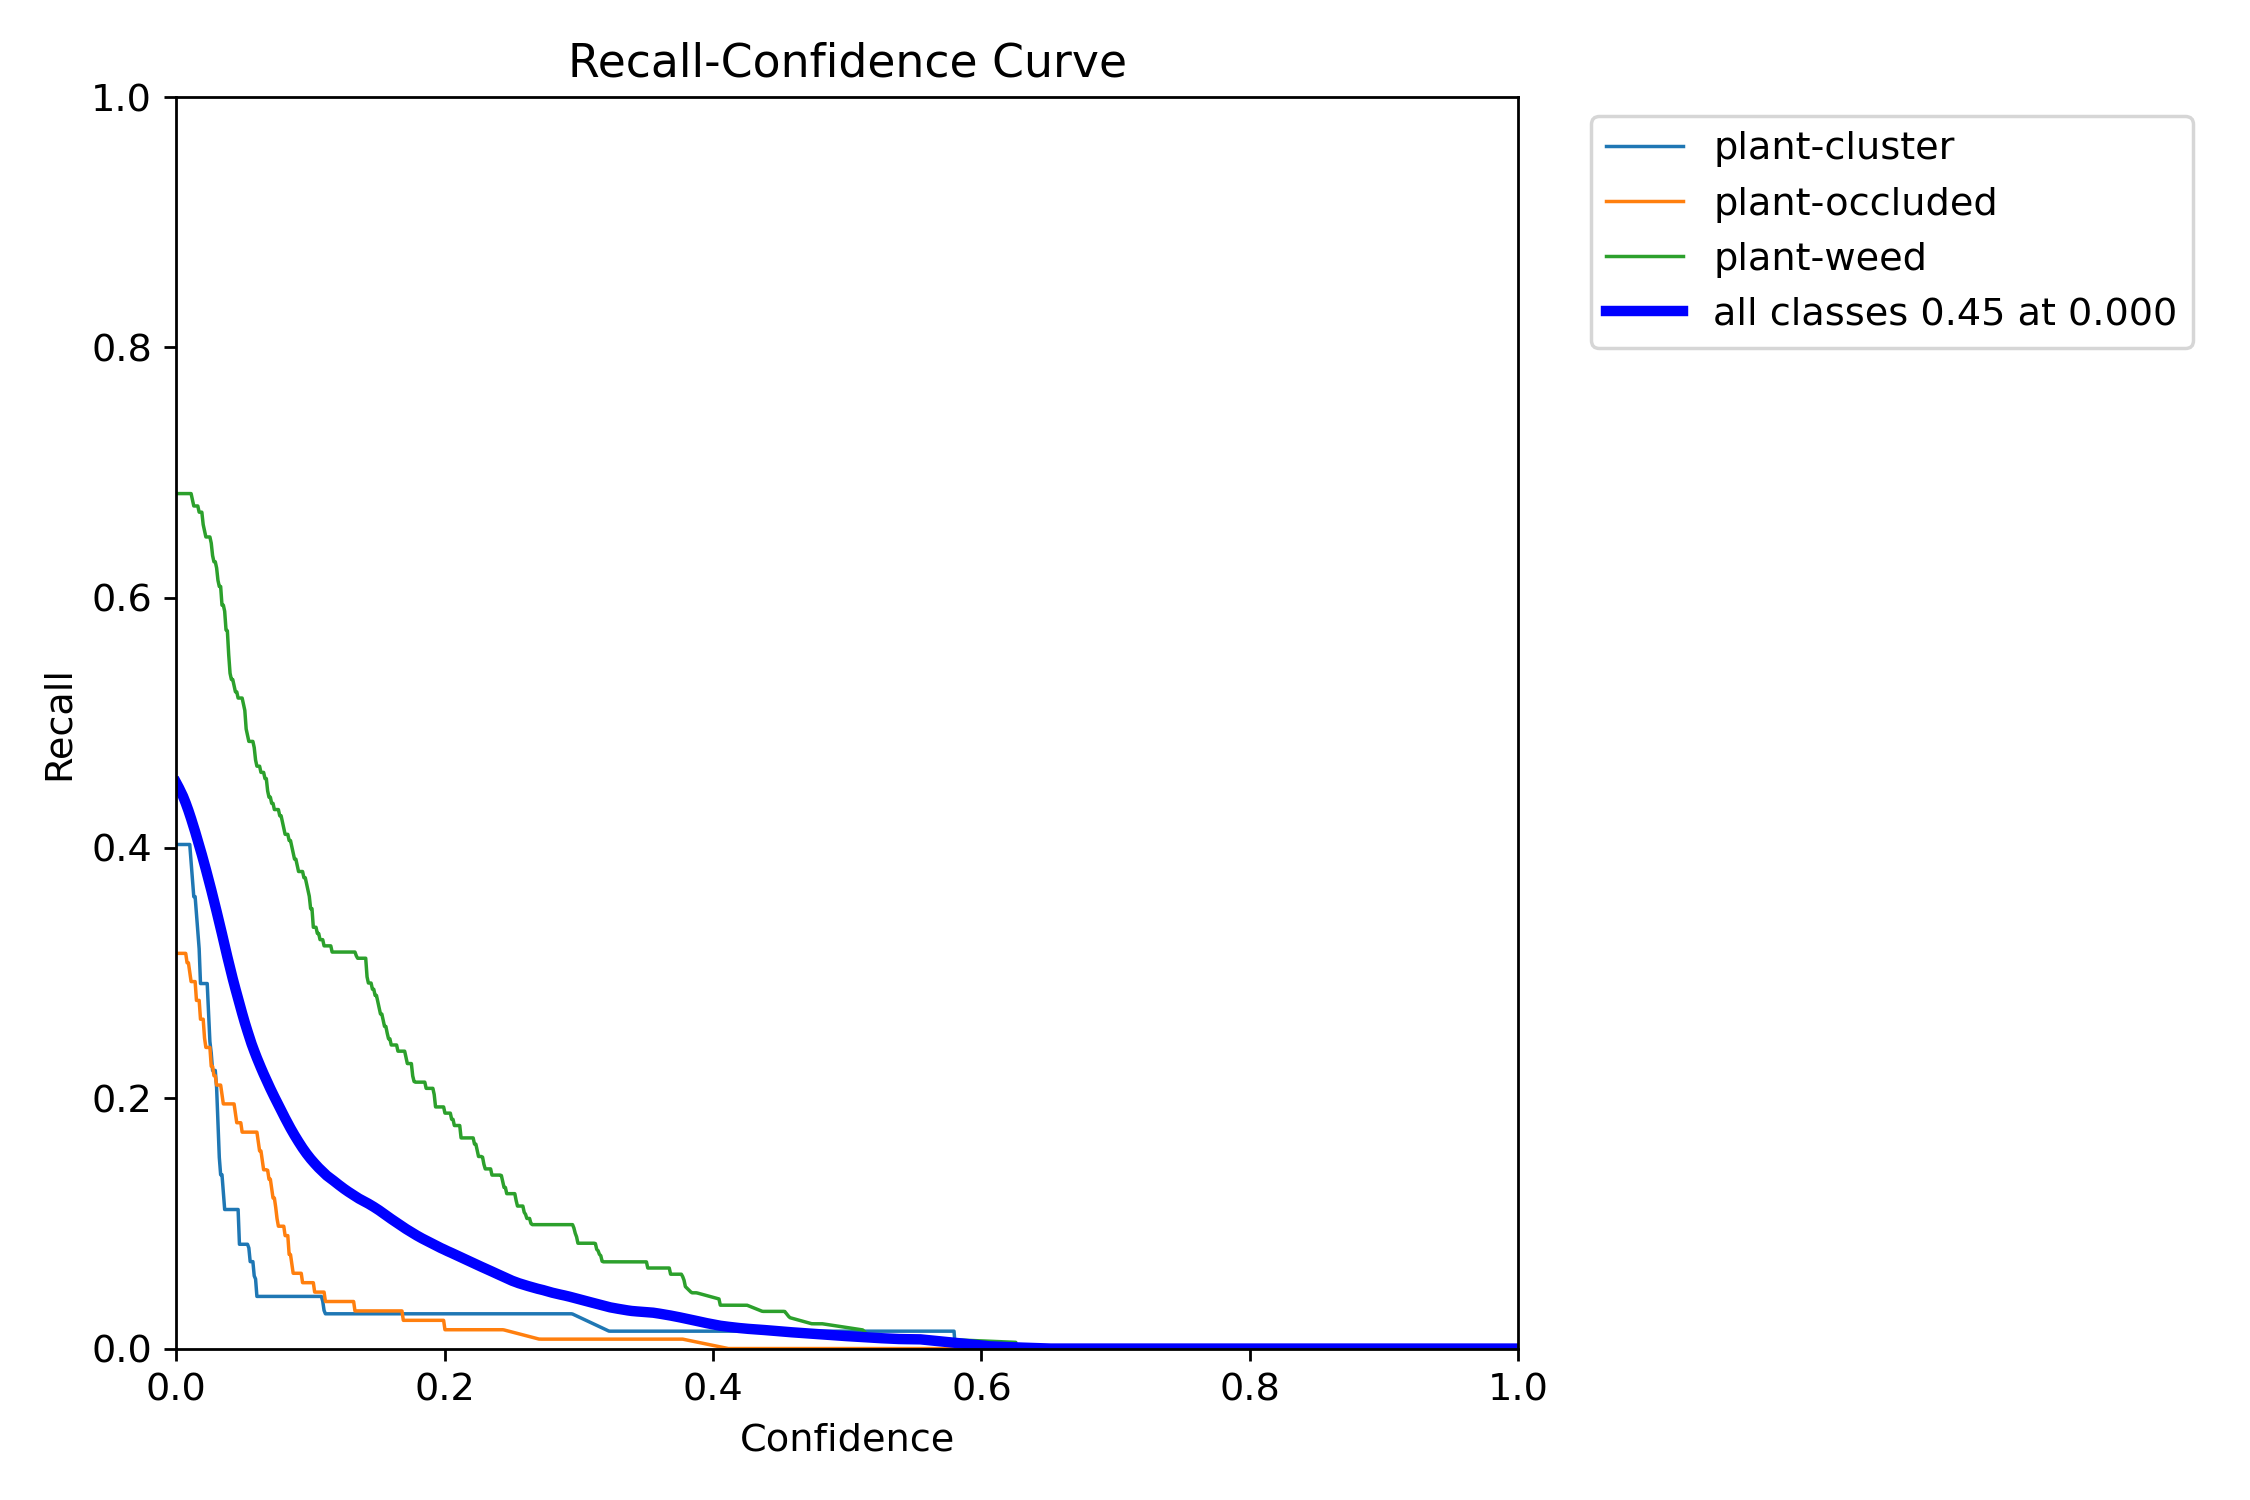

In [308]:
file_name = os.path.join(folder, "R_curve.png")
Image(file_name, width=scale)

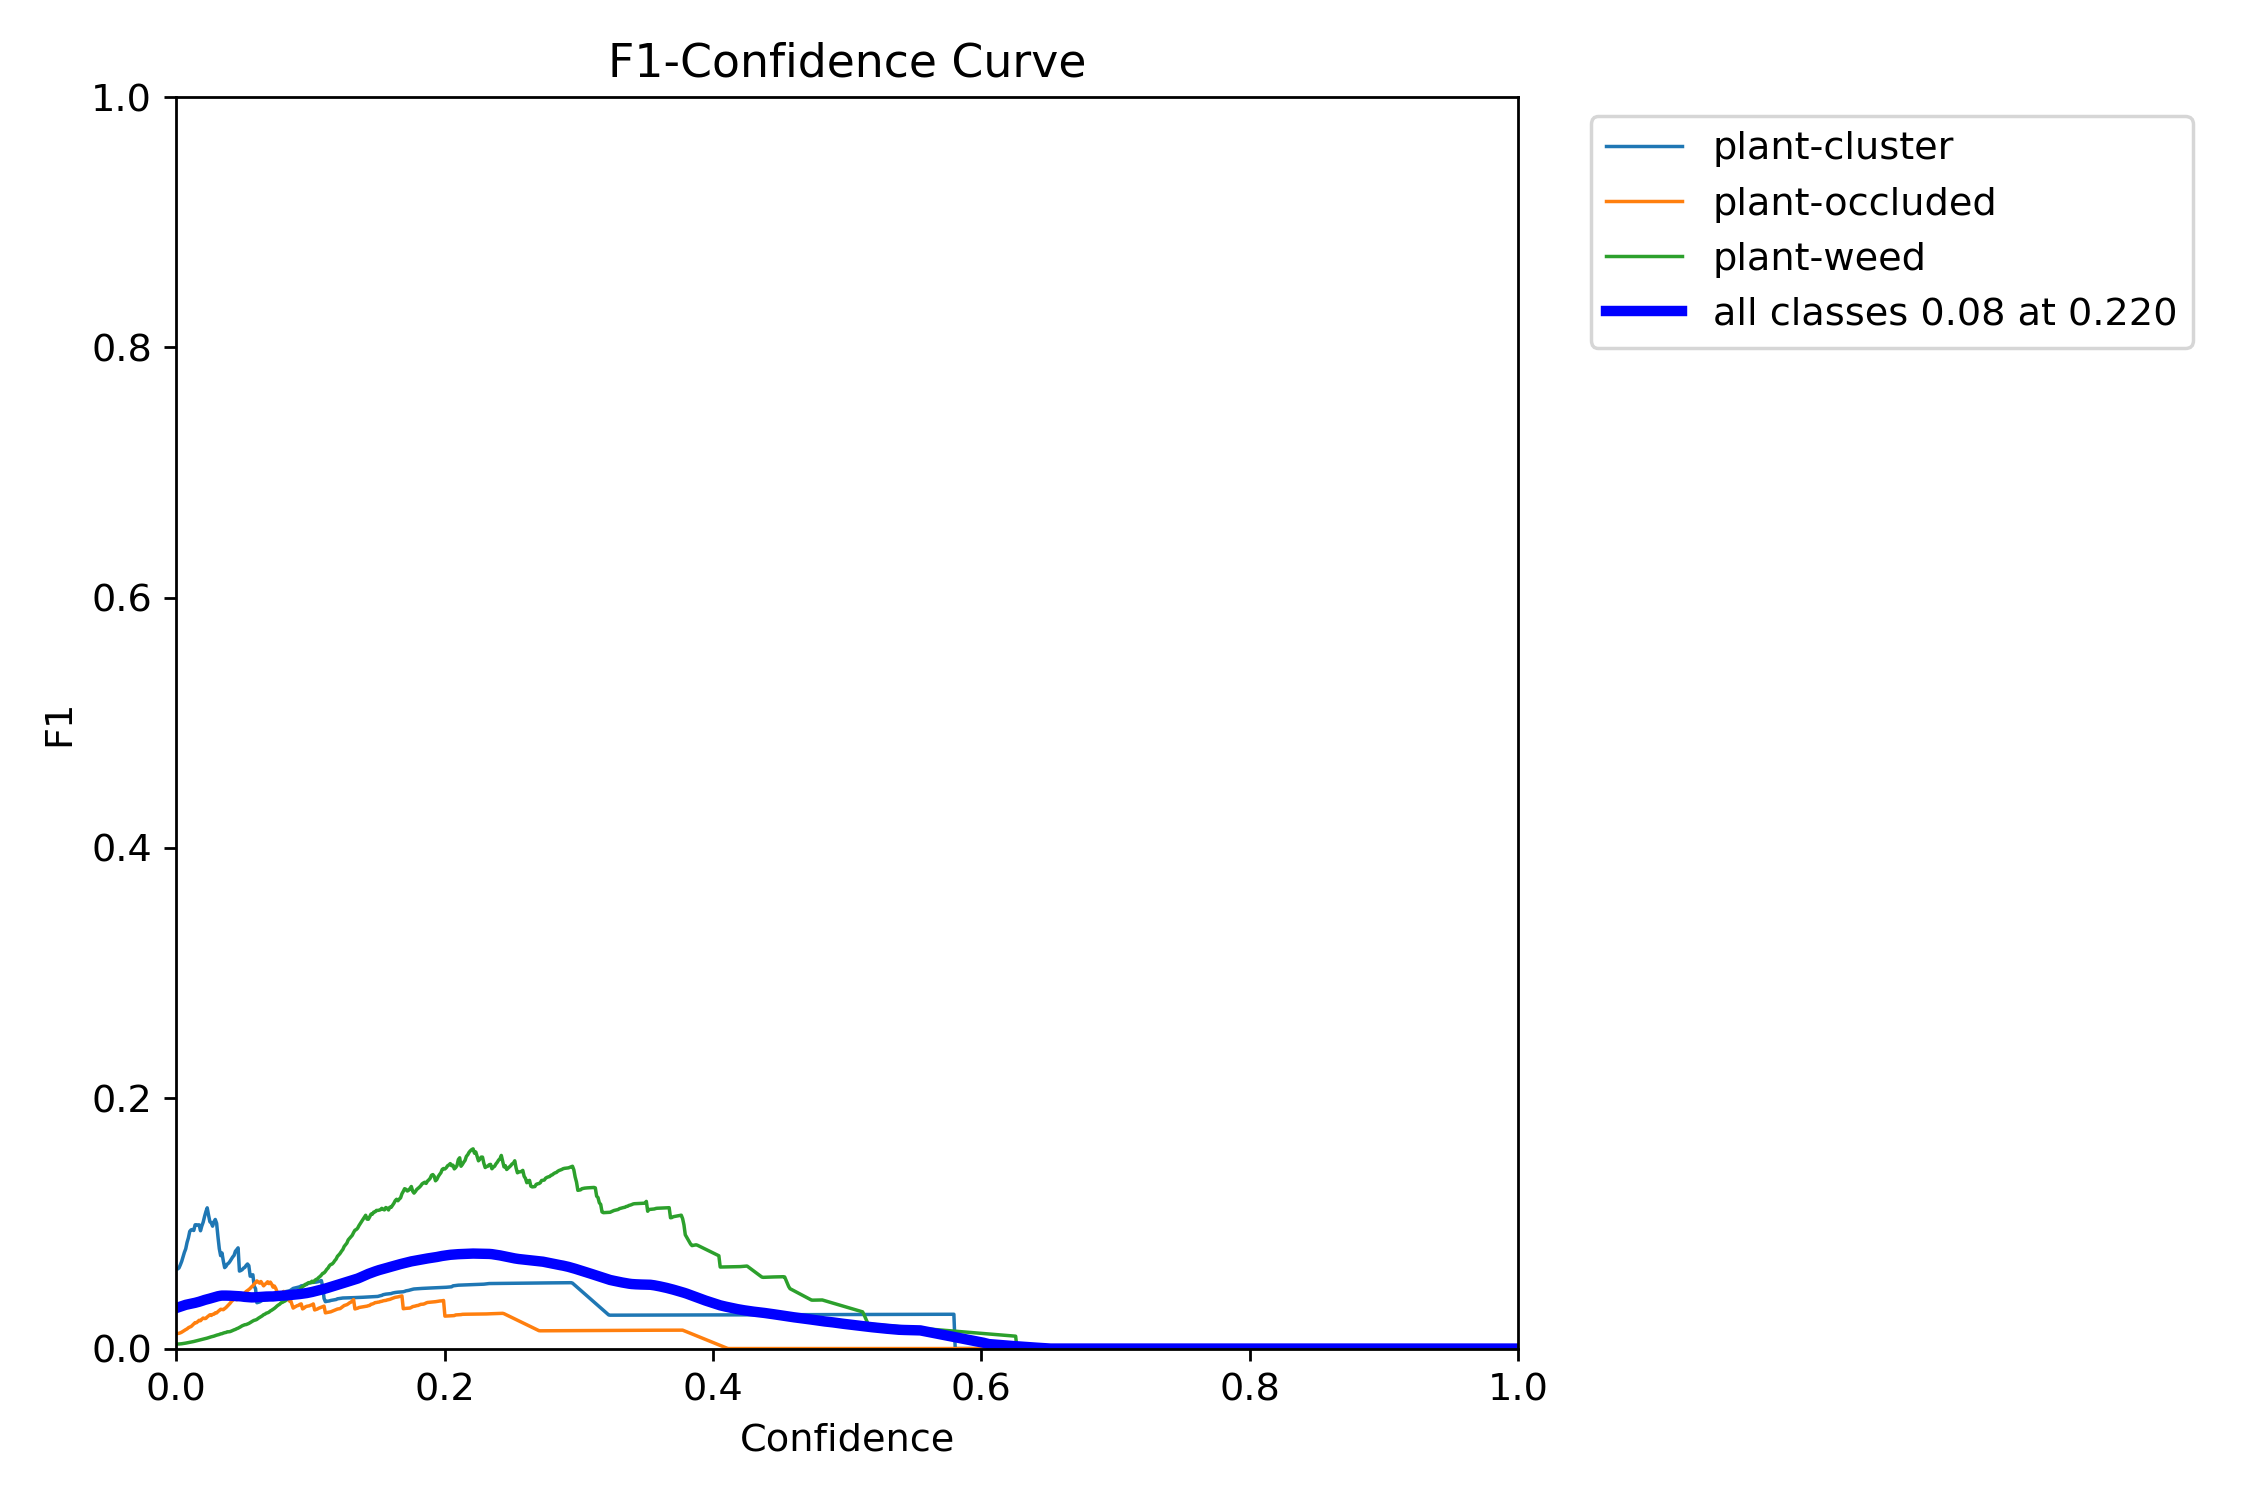

In [309]:
file_name = os.path.join(folder, "F1_curve.png")
Image(file_name, width=scale)

From the F1 curve, the confidence value that optimizes precision and recall is 0.231. In many cases a higher confidence value is desirable.

### Conclusiones

1. **Pérdidas de entrenamiento y validación  (Losses)**

- 

2. **Métricas de validación (Precisión, Recall, mAP)**

- 

3. **Evolución de la Tasa de Aprendizaje (Learning Rate, LR)** 

- 

----

# Métricas generales

In [310]:
best_models.index = ['1º TRAIN','2º TRAIN','3º TRAIN']

In [311]:
best_models.sort_values(by='metrics/mAP50(B)', ascending=True)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2,train_time
1º TRAIN,90,887.530,2.96676,2.12934,1.54329,0.06910,0.11065,0.02936,0.00731,2.76700,20.9898,1.41812,0.000170,0.000170,0.000170,16.362667
2º TRAIN,37,249.075,3.05612,2.11753,1.41037,0.07591,0.09076,0.03722,0.00968,3.05066,3.7909,1.48528,0.000920,0.000920,0.000920,10.890100
3º TRAIN,65,243.408,2.81860,2.04292,1.62350,0.19256,0.07203,0.05199,0.01247,2.11288,53.8067,1.22990,0.000524,0.000524,0.000524,6.174617


## Graphs

In [312]:
def plot_metric(metric, ylabel, title, max_epoch=None):
    """
    Plots a metric from multiple DataFrames with an optional limit on the x-axis.

    Args:
        metric (str): The column name representing the metric to plot.
        ylabel (str): The label for the y-axis.
        title (str): The title of the plot.
        max_epoch (int, optional): The maximum epoch to display on the x-axis. Defaults to None (no limit).
    """
    plt.figure(figsize=(15, 5))
    plt.plot(df1["epoch"], df1[metric], label=best_models.index[0], linestyle="--", marker="o", markersize=4)
    plt.plot(df2["epoch"], df2[metric], label=best_models.index[1], linestyle="--", marker="s", markersize=4)
    plt.plot(df3["epoch"], df3[metric], label=best_models.index[2], linestyle="--", marker="d", markersize=4)
    #plt.plot(df4["epoch"], df4[metric], label=best_models.index[3], linestyle="--", marker="*", markersize=4)
    plt.xlabel("Epochs")
    plt.ylabel(ylabel)
    plt.title(title)
    if max_epoch is not None:
        plt.xlim(0, max_epoch)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Training and Validation Losses

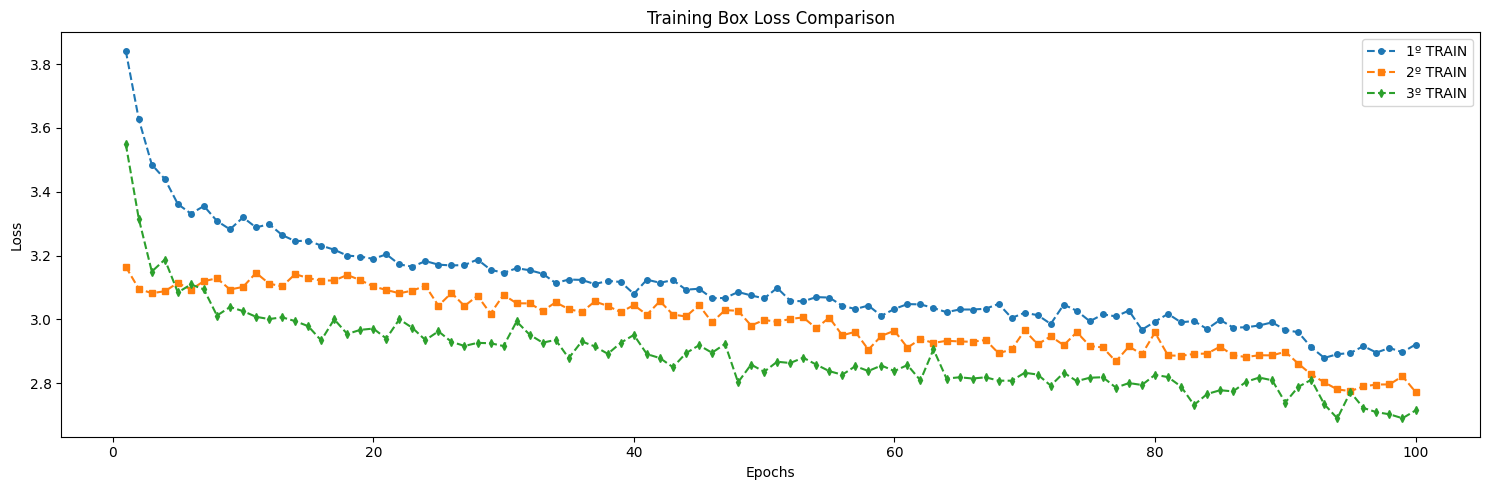

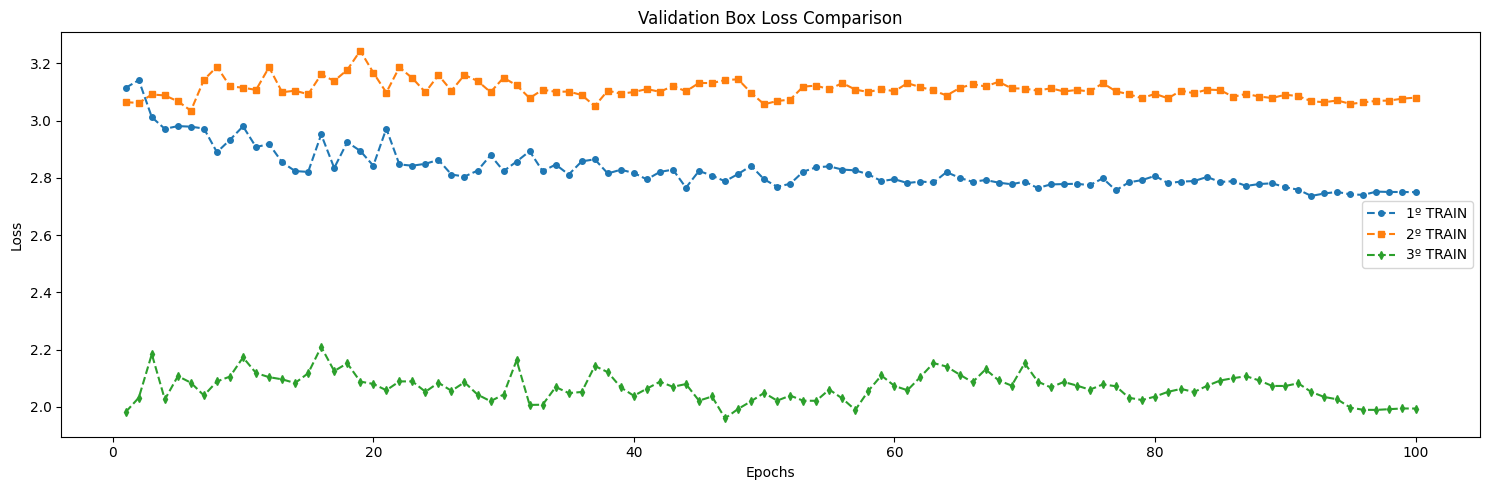

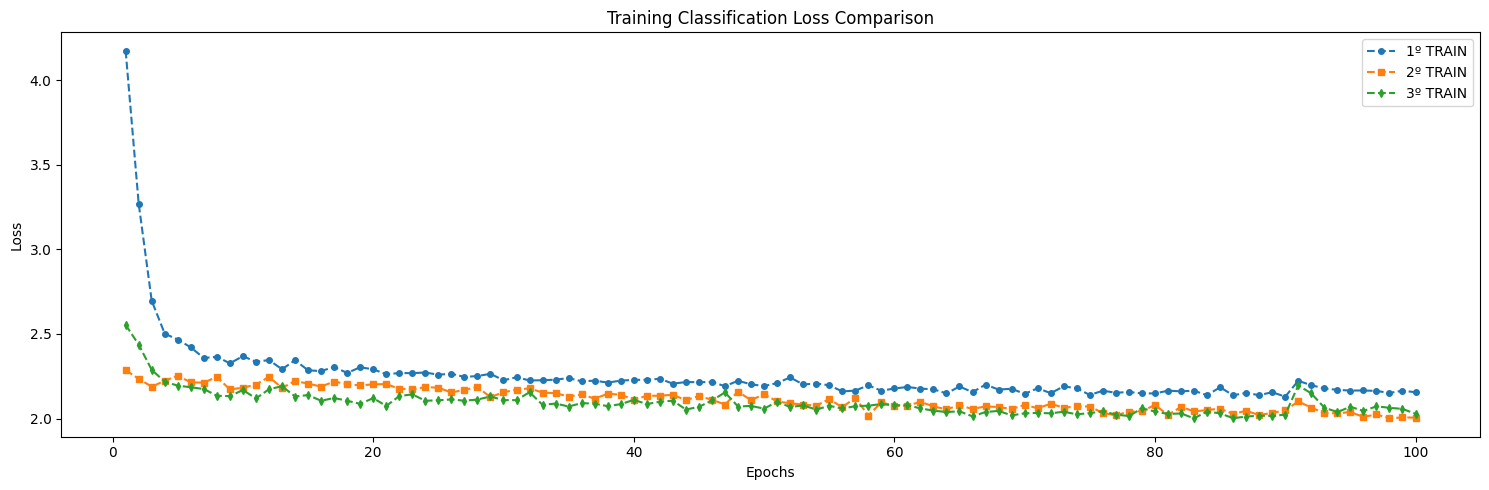

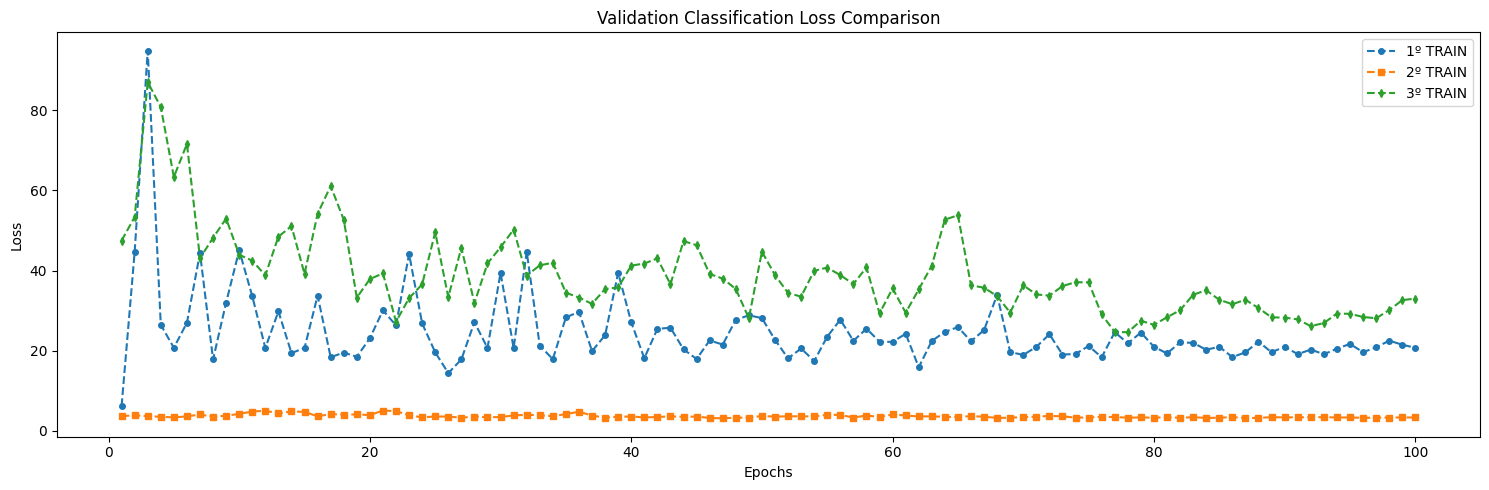

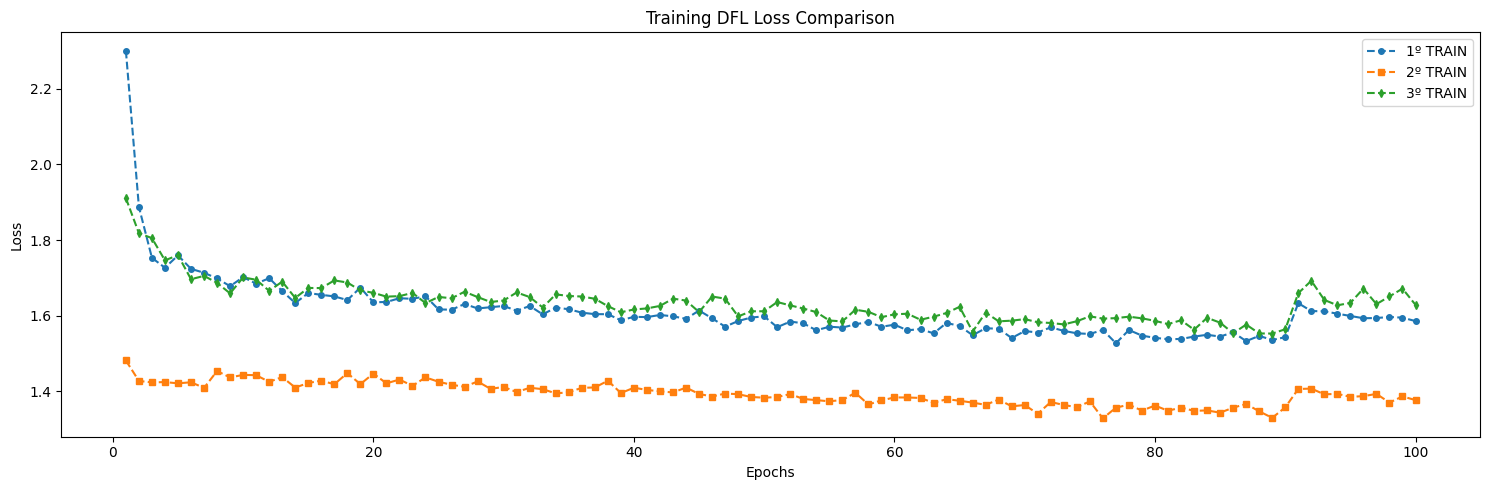

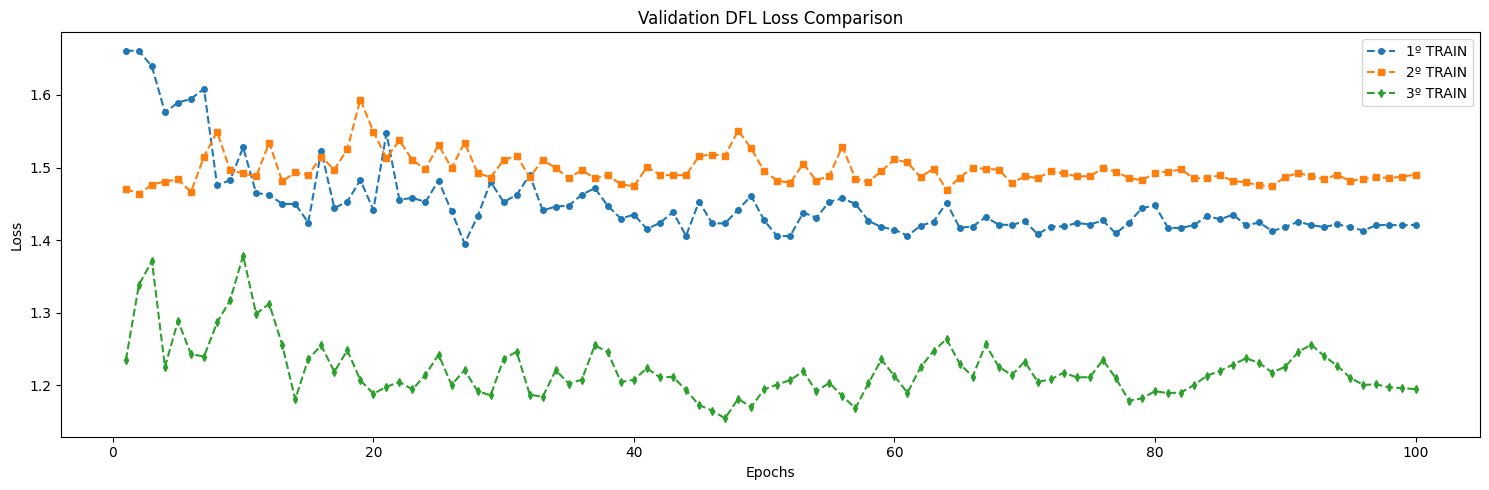

In [313]:
# Plot Training and Validation Losses
plot_metric("train/box_loss", "Loss", "Training Box Loss Comparison")
plot_metric("val/box_loss", "Loss", "Validation Box Loss Comparison")

plot_metric("train/cls_loss", "Loss", "Training Classification Loss Comparison")
plot_metric("val/cls_loss", "Loss", "Validation Classification Loss Comparison")

plot_metric("train/dfl_loss", "Loss", "Training DFL Loss Comparison")
plot_metric("val/dfl_loss", "Loss", "Validation DFL Loss Comparison")

### Performance Metrics

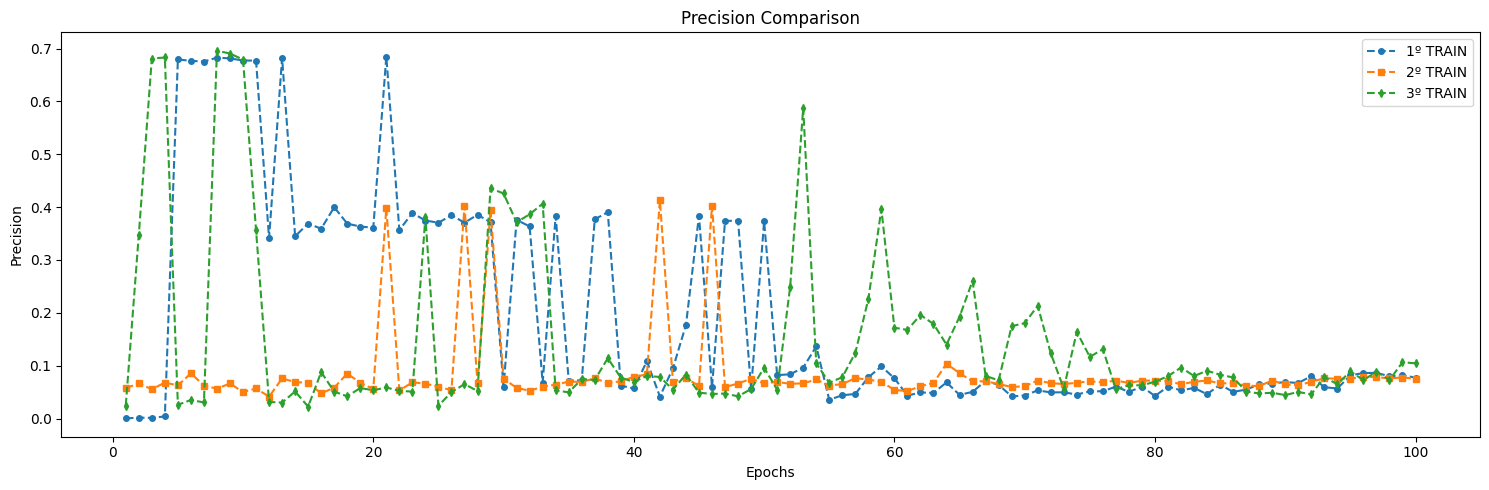

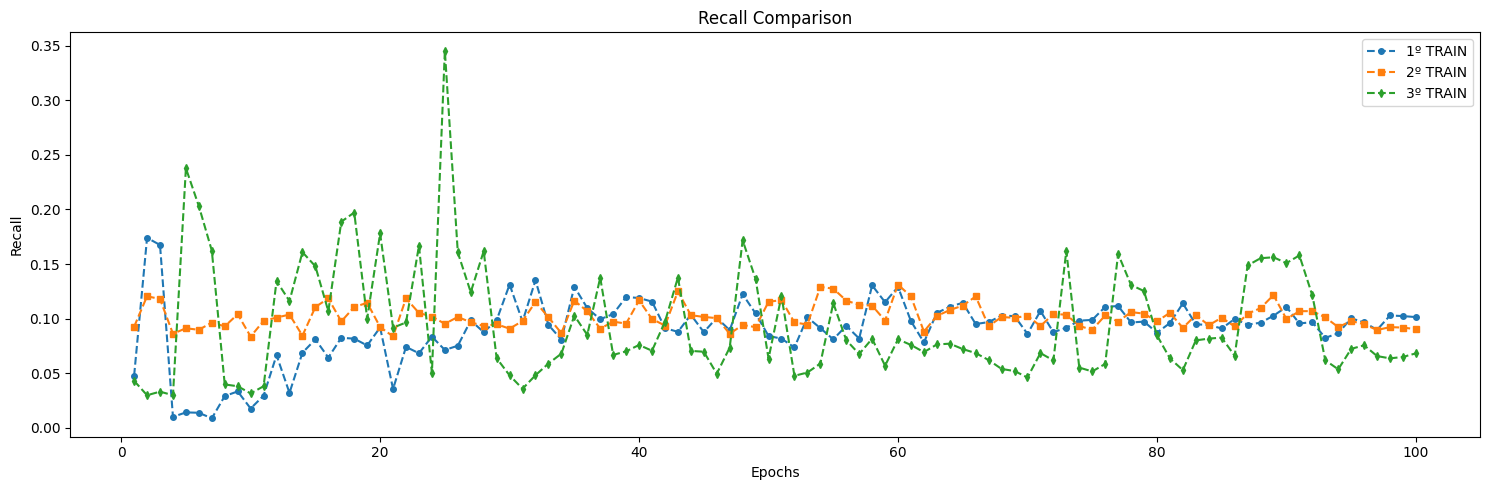

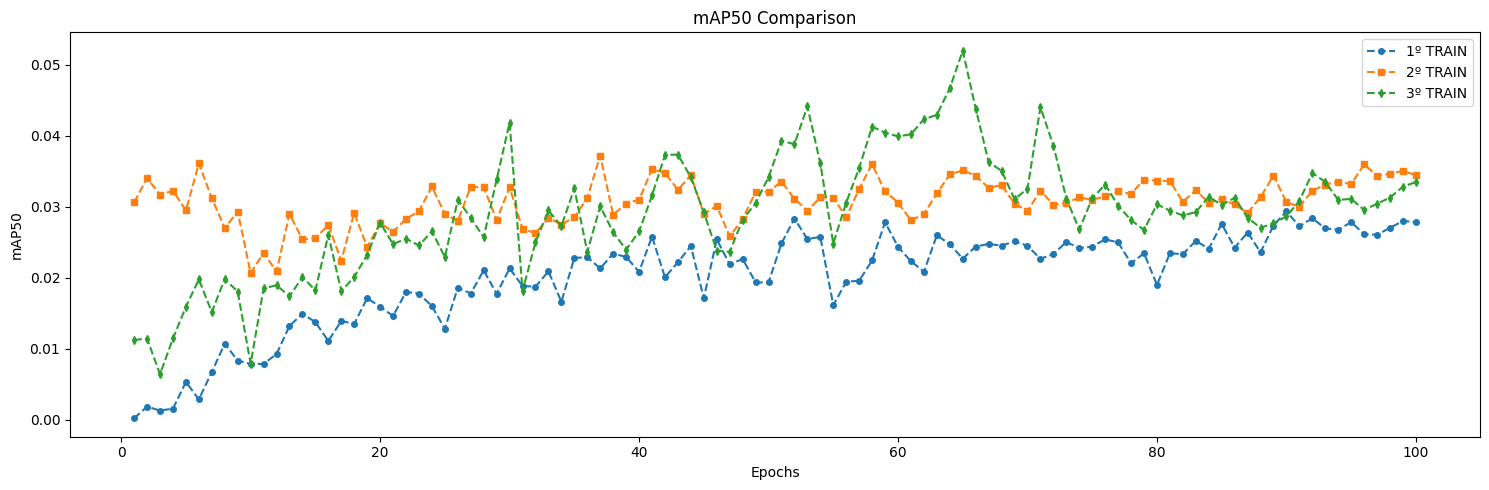

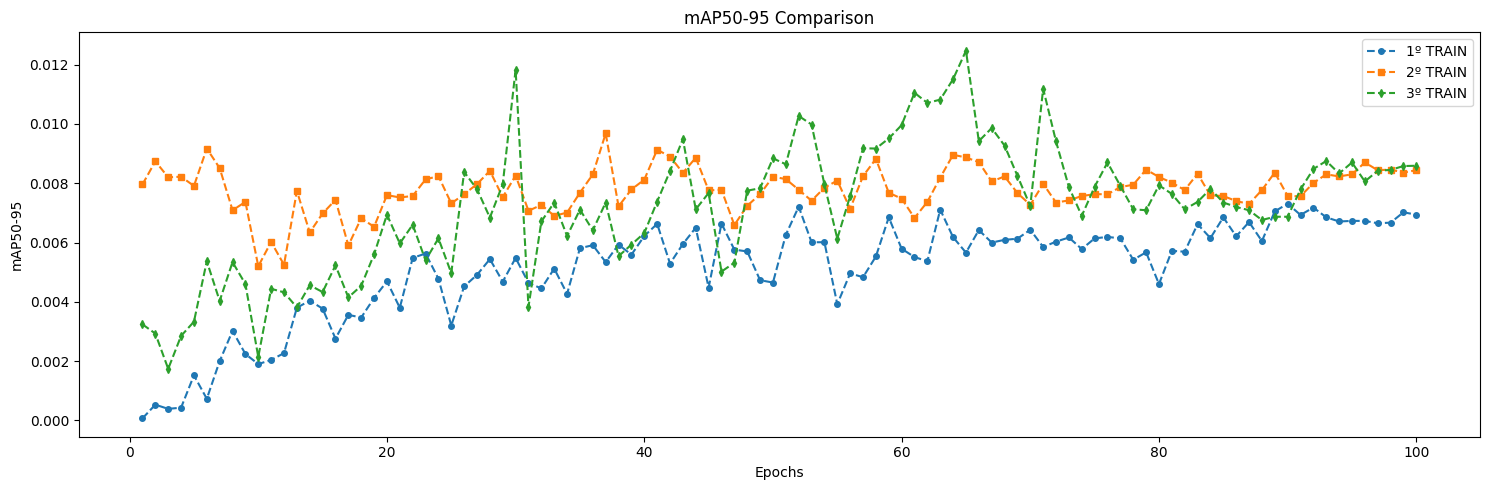

In [314]:
# Plot Performance Metrics
plot_metric("metrics/precision(B)", "Precision", "Precision Comparison")
plot_metric("metrics/recall(B)", "Recall", "Recall Comparison")
plot_metric("metrics/mAP50(B)", "mAP50", "mAP50 Comparison")
plot_metric("metrics/mAP50-95(B)", "mAP50-95", "mAP50-95 Comparison")

### Learning Rate

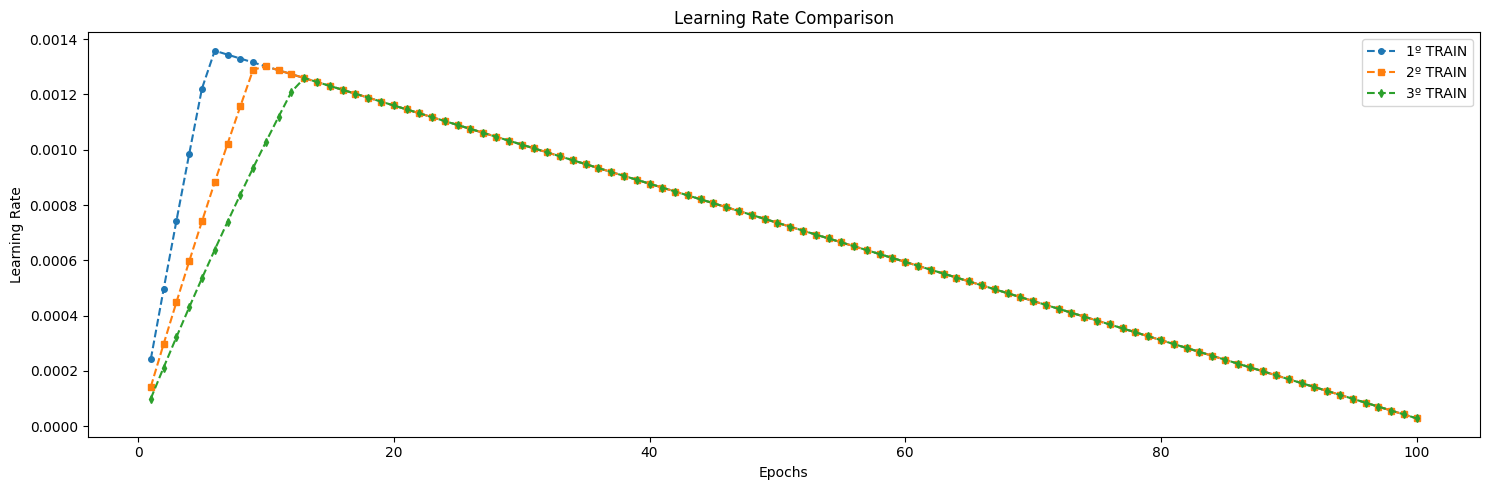

In [315]:
# Plot Learning Rate
plot_metric("lr/pg0", "Learning Rate", "Learning Rate Comparison")

## Resumen de los Experimentos

| Experiment | Dataset (Size) | Images | Tiles | Tags | Train/Valid (%) | Train Time (min) | Inf Time (ms) | Total detections | True Positives | False Positives | False Negatives | mAP@0.5 |
|------------|------|------|--------------|---------|------|------|----------------|---------------|---------------|---------------|---------------|--------|
| **1º TRAIN** | Small & Mid | 4 | 1472 |  | 50% / 50% | *0* | ***0*** |  | % | % | % | ***0*** |
| **2º TRAIN** | Small | 2 | 736 |  | 50% / 50% | *0* | ***0*** |  | % | % | % | ***0*** |
| **3º TRAIN** | Mid | 2 | 736 |  | 50% / 50% | *0* | ***0*** |  | % | % | % | ***0*** |

## Comparación de los Entrenamientos

### Análisis del Dataset
1. **Cantidad de imágenes y etiquetas**:  
  -  

2. **Distribución de Train/Valid**:  
  -  

3. **Tamaño de imágenes (small vs mid)**:  
  -  

### Análisis de los Hiperparámetros
- **Modelo (yolov8n)**: Se mantuvo constante en todos los entrenamientos, lo que permite una comparación justa.  
- **Epochs (100)**: En los tres experimentos, el modelo parece alcanzar su rendimiento máximo antes de completar todas las épocas, lo que podría indicar que no se necesita entrenar tantas iteraciones.  
- **Batch Size (64)**: Se mantiene igual en todos los experimentos.  
- **Freeze (10)**: Congelar los primeros 10 capas del modelo en los tres entrenamientos podría estar limitando la capacidad de ajuste en las primeras etapas.  

### Análisis de Resultados
#### Métricas Generales
1. **Precisión (Precision) y Recall**:  
  -  

2. **mAP50**:  
  - 
  
3. **Confusión entre clases (False Positives y False Negatives)**:  
  - 
  
### Conclusiones Generales
1. 

# Conclusión Final


## Estrategias para Próximos Entrenamientos
1. **Dataset**
- 

2. **Hiperparámetros**
-  

3. **Optimización del Modelo**
- 

4. **Evaluación y Métricas**
-  